# Seoul Bike Sharing, 2015–2024 — Multivariate Analysis

**Second notebook** in the v4 series (segmented by session). The first one (`Seoul_Bike_2015-2024_EDA.ipynb`) covered coverage, integrity, and growth panorama; this one responds to **which variables are related to demand** and resolves the **2020 anomaly** before it contaminates the correlations.

The toolkit in `src/` includes a *loader* that preserves column names, allowing functions to be executed. However, two adaptations are necessary for the 10 years of data:

1. **110× Trend.** Demand grew from ~46 (2015) to ~5,000 (2023) average rentals per hour. Any correlation on raw demand would be dominated by "the system grew," not the real relationship with climate/hour/seasonality. **Solution:** de-trend demand using a **continuous moving average baseline** (ratio-to-moving-average, Section 2) — removes business growth without breaking continuity from dec to jan, and all analyses run on this index.
2. **2020 Anomaly.** Demand drops to a fraction of neighboring years in May–Dec/2020 and needs to be diagnosed and signaled **before** multivariate analysis.

> Scope Note: This notebook covers multivariate analysis. Univariate distributions (KDE/boxplots of target and climate) are left for a dedicated `Distribution` notebook.


In [1]:
import warnings
warnings.filterwarnings('ignore')

# Section 0: Environment setup
import sys
from pathlib import Path
PROJECT_ROOT = next(
    filter(
        lambda candidate: (
            (candidate / 'src').is_dir()
            and (candidate / 'notebooks').is_dir()
        ),
        (Path.cwd(), *Path.cwd().parents),
    )
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import read_data
from src.feature_engineering import build_preprocessing_pipeline
from src.plotting import set_graph_parameters
from src.i18n import make_lang
from src import eda, seasonal
from src import feature_selection as fs
from src import stats_tests as st

lang = make_lang('en')          # PT canônico — passthrough, sem chamadas de rede
set_graph_parameters()
plt.rcParams['axes.grid'] = False

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

full = build_preprocessing_pipeline().fit_transform(read_data())
TARGET = 'Rented Bike Count'
full['Year'] = full['Date'].dt.year
rows_label = lang({'rows': 'linhas'})['rows']
print(f'{len(full):,} {rows_label} | {full["Date"].min().date()} -> {full["Date"].max().date()}')
eda.localize_preview(full[['Date', TARGET, 'Year', 'Month', 'Temperature(C)', 'Seasons']], lang=lang).head()


81,018 rows | 2015-09-19 -> 2024-12-31


,Date,Rented Bike Count,Year,Month,Temperature(C),Seasons
0,2015-09-19 00:00:00,1,2015,9,20.2,Autumn
1,2015-09-19 01:00:00,2,2015,9,19.5,Autumn
2,2015-09-19 07:00:00,1,2015,9,17.2,Autumn
3,2015-09-19 08:00:00,2,2015,9,19.2,Autumn
4,2015-09-19 09:00:00,21,2015,9,21.1,Autumn


### Missing Value Imputation (Weather)

Unlike the v3 dataset (no missing values), this dataset contains NaN in weather variables — `Cloud Cover (oktas)` ~6.8%, and a few dozen in `Wind speed`, `Ground Temp`, `Temperature`, `Humidity`, `Dew point`, `Visibility`. I impute by **median** (mirroring the `SimpleImputer(strategy='median')` from the modeling pipeline), so that tests based on `SelectKBest`/OLS do not break with NaN. The target count does not have missing values.


In [2]:
full, na_before = eda.impute_numeric_median(full)
msg = lang({
    'imputed': 'Imputados (mediana) — contagem de NaN antes:',
    'remaining': 'NaN restantes em colunas numéricas:',
})
print(msg['imputed'])
print(na_before.sort_values(ascending=False).to_string())
print(f'\n{msg["remaining"]}', int(full.select_dtypes(include=[np.number]).isna().sum().sum()))


Imputed (median) — NaN count before:
Cloud Cover (oktas)         5482
Wind speed (m/s)             123
Ground Temp(C)                32
Temperature(C)                 5
Humidity(%)                    4
Dew point temperature(C)       2
Visibility (10m)               1

Remaining NaNs in numerical columns: 0


## 1. Resolving the 2020 Anomaly (Integrity Gate)

Reproducible Rule: For each month, the average demand of 2020 is compared to the **expected trend** — the geometric interpolation between the same month of 2019 and 2021 (geometric because the growth is multiplicative). Months of 2020 below **60%** of the expected are marked as anomalous.


In [3]:
diag = seasonal.anomaly_diagnosis(full, TARGET)
anomalous_months = diag.anomalous_months

report = seasonal.anomaly_report_table(diag, lang=lang)
fmt = {col: '{:,.1f}' for col in report.columns[:-1]}
fmt[report.columns[-2]] = '{:.3f}'   # coluna de razão
display(report.style.format(fmt))

msg = lang({'flagged': 'Meses anômalos de 2020 (razão < 0.60)'})
print(f'{msg["flagged"]}: {anomalous_months}')


,Mean 2019,Mean 2020,Mean 2021,Geometric reference,Ratio 2020 / reference,Flagged
Month,,,,,,
1,645.9,963.6,965.3,789.6,1.220,False
2,680.2,988.9,"1,714.7","1,080.0",0.916,False
3,"1,175.1","1,750.2","2,667.5","1,770.5",0.989,False
4,"1,948.8","1,829.7","3,794.6","2,719.3",0.673,False
5,"2,921.7","1,209.6","3,684.2","3,280.8",0.369,True
6,"3,015.7","1,847.6","4,497.6","3,682.9",0.502,True
7,"2,735.3","1,726.1","4,233.1","3,402.8",0.507,True
8,"2,648.8",256.6,"3,868.1","3,200.9",0.080,True
9,"2,888.3",435.0,"4,181.2","3,475.1",0.125,True


Anomalous months in 2020 (ratio < 0.60): [5, 6, 7, 8, 9, 10, 11, 12]


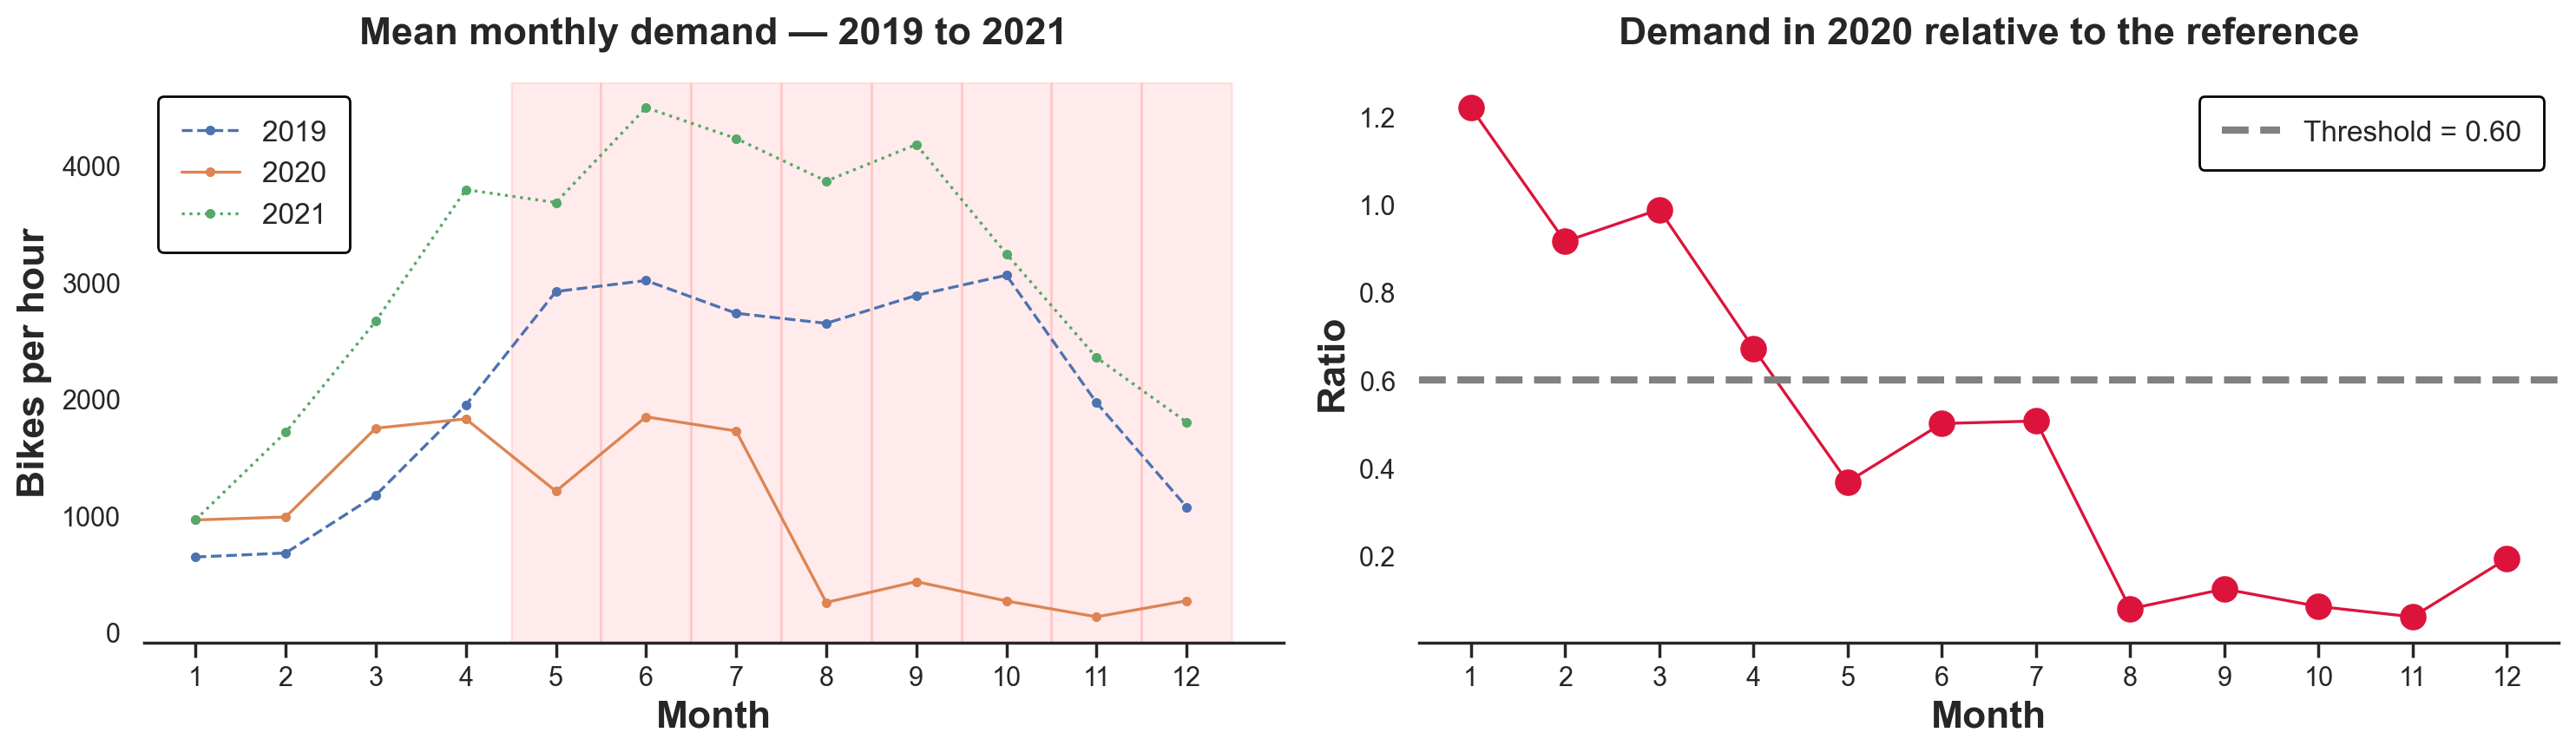

In [4]:
fig, axes = seasonal.plot_anomaly_diagnosis(diag, lang=lang)
plt.show()


>**`Insights from diagnosis and decision:`**
>
>The **drop is not for the whole year**: Jan–Apr/2020 follows the trend (ratio ≈ 0.9–1.2), but from **May to December** the demand falls to 8–50% of what was expected — total collapse in Aug–Nov (ratio 0.06–0.13) — and **recovers 100% in 2021**.
>
>Signals that weigh against "pure COVID behavioral effect". A drop of ~90% sustained for 5 months is too severe for a change in behavior, the use of bikes in Seoul *increased* during the pandemic (mode with social distancing). No hour with `count==0` in any year and stamp coverage is normal in 2020 — the values are *implausibly low*, not absent, compatible with **partial / subset of station data** reporting during this period.
>
>**Cause: uncertain, probable data collection artifact.** Therefore, instead of excluding data or assuming COVID, a regime flag `is_anomalous_2020` is adopted in the affected window (neutral name) and the **lines are kept** — the analysis and model isolate the regime, and Jan–Apr/2020 (normal) remains intact.


In [5]:
# Flag data-driven a partir da regra de limiar acima (não datas escolhidas à mão).
full['is_anomalous_2020'] = seasonal.anomaly_mask(full, diag).astype(int)
n_anom = int(full['is_anomalous_2020'].sum())
msg = lang({
    'flag': 'is_anomalous_2020 = 1 para',
    'rows': 'linhas',
    'months': '-> meses de 2020',
})
print(f'{msg["flag"]} {n_anom:,} {msg["rows"]} ({100 * full["is_anomalous_2020"].mean():.1f}%) '
      f'{msg["months"]} {diag.anomalous_months}')


is_anomalous_2020 = 1 for 5,858 rows (7.2%) -> months in 2020 [5, 6, 7, 8, 9, 10, 11, 12]


## 2. Detrending Demand (Continuous Moving Baseline)

The growth of approximately **110×** between 2015 and 2023 is treated in this notebook as a change in **level and scale of the system** — compatible with expansion of bicycles, stations, and users —, and not as evidence of a meteorological change of equivalent magnitude. The cause of this growth cannot be identified solely with these observational data; nonetheless, the low-frequency component must be removed so that the intranual associations with time, season, and climate are not confused with the year in which each observation was recorded. Calendar-year normalization is also avoided: December of one year and January of the following year would be divided by distinct bases, and an artificial step would be introduced in the middle of the same winter.

**Method (*ratio-to-moving-average*):** First, the hourly count is aggregated by the daily mean. Then, a base line $\widehat{T}_t$ is estimated by a **365-day centered moving average** (`min_periods=180`), and the hourly demand is transformed into the multiplicative index $I_t = Y_t / \widehat{T}_t$. With daily aggregation, it is avoided that 365 observations are confused with only 365 hours; by the annual window, seasonality is attenuated in the base estimation and a discontinuity on 1st/Jan is avoided. Seasonality is not, however, canceled by construction: relative seasonal, meteorological, and irregular variations are preserved in the index around 1. This formulation follows the classical multiplicative decomposition by ratio to moving average described by [Miller and Williams (2003)](https://doi.org/10.1016/S0169-2070(02)00077-8).

**Anomaly Treatment and Coverage:** Days marked by `is_anomalous_2020` are excluded only from the base estimation, so that the collapse of May–Dec/2020 does not artificially shift the trend downward. Since this interval is longer than the tolerance allowed by `min_periods=180`, part of the own anomalous window remains without sufficient valid observations and receives index `NaN`; these lines are subsequently excluded from the multivariate table. Therefore, the exclusion of the anomaly should not be interpreted as its imputation or correction.

**Scope of Use:** As previous and subsequent observations are used by a centered window, the index is suitable for **retrospective analysis** performed in this notebook. It should not be used as a feature available in real-time nor as a causal transformation for prediction. In the series' extremities, bases supported by less than 365 days may be accepted by the minimum of 180 observations; therefore, partial meteorological years should be interpreted separately from complete years.


In [6]:
demand_index = seasonal.demand_index_moving_average(
    full, anomaly_mask=full['is_anomalous_2020'].astype(bool))
full['met_year'] = seasonal.meteorological_year(full['Date'])

msg = lang({
    'defined': 'índice definido para',
    'rows_note': 'linhas; NaN é produzido onde há menos de 180 dias-base válidos',
    'undefined': 'linhas indefinidas estão dentro da janela anômala de 2020 sinalizada',
    'mean_by': ('Índice médio por ano meteorológico '
                '(apenas anos completos e não anômalos são diretamente comparáveis):'),
})
print(f'{msg["defined"]} {demand_index.notna().sum():,}/{len(full):,} '
      f'({100*demand_index.notna().mean():.1f}%) — {msg["rows_note"]}')
undefined_in_anomaly = (demand_index.isna() & full['is_anomalous_2020'].astype(bool)).sum()
print(f'{undefined_in_anomaly:,} {msg["undefined"]}')
print(f'\n{msg["mean_by"]}')
print(demand_index.groupby(full['met_year']).mean().round(3).to_string())


index defined for 75,304/81,018 (92.9%) — rows; NaN is produced where fewer than 180 valid baseline days are available
5,714 undefined rows fall within the flagged anomalous 2020 window

Mean index by meteorological year (only complete, non-anomalous years are directly comparable):
met_year
2015    1.090
2016    0.943
2017    1.004
2018    0.962
2019    1.006
2020    0.754
2021    0.997
2022    1.008
2023    0.998
2024    0.961
2025    0.587


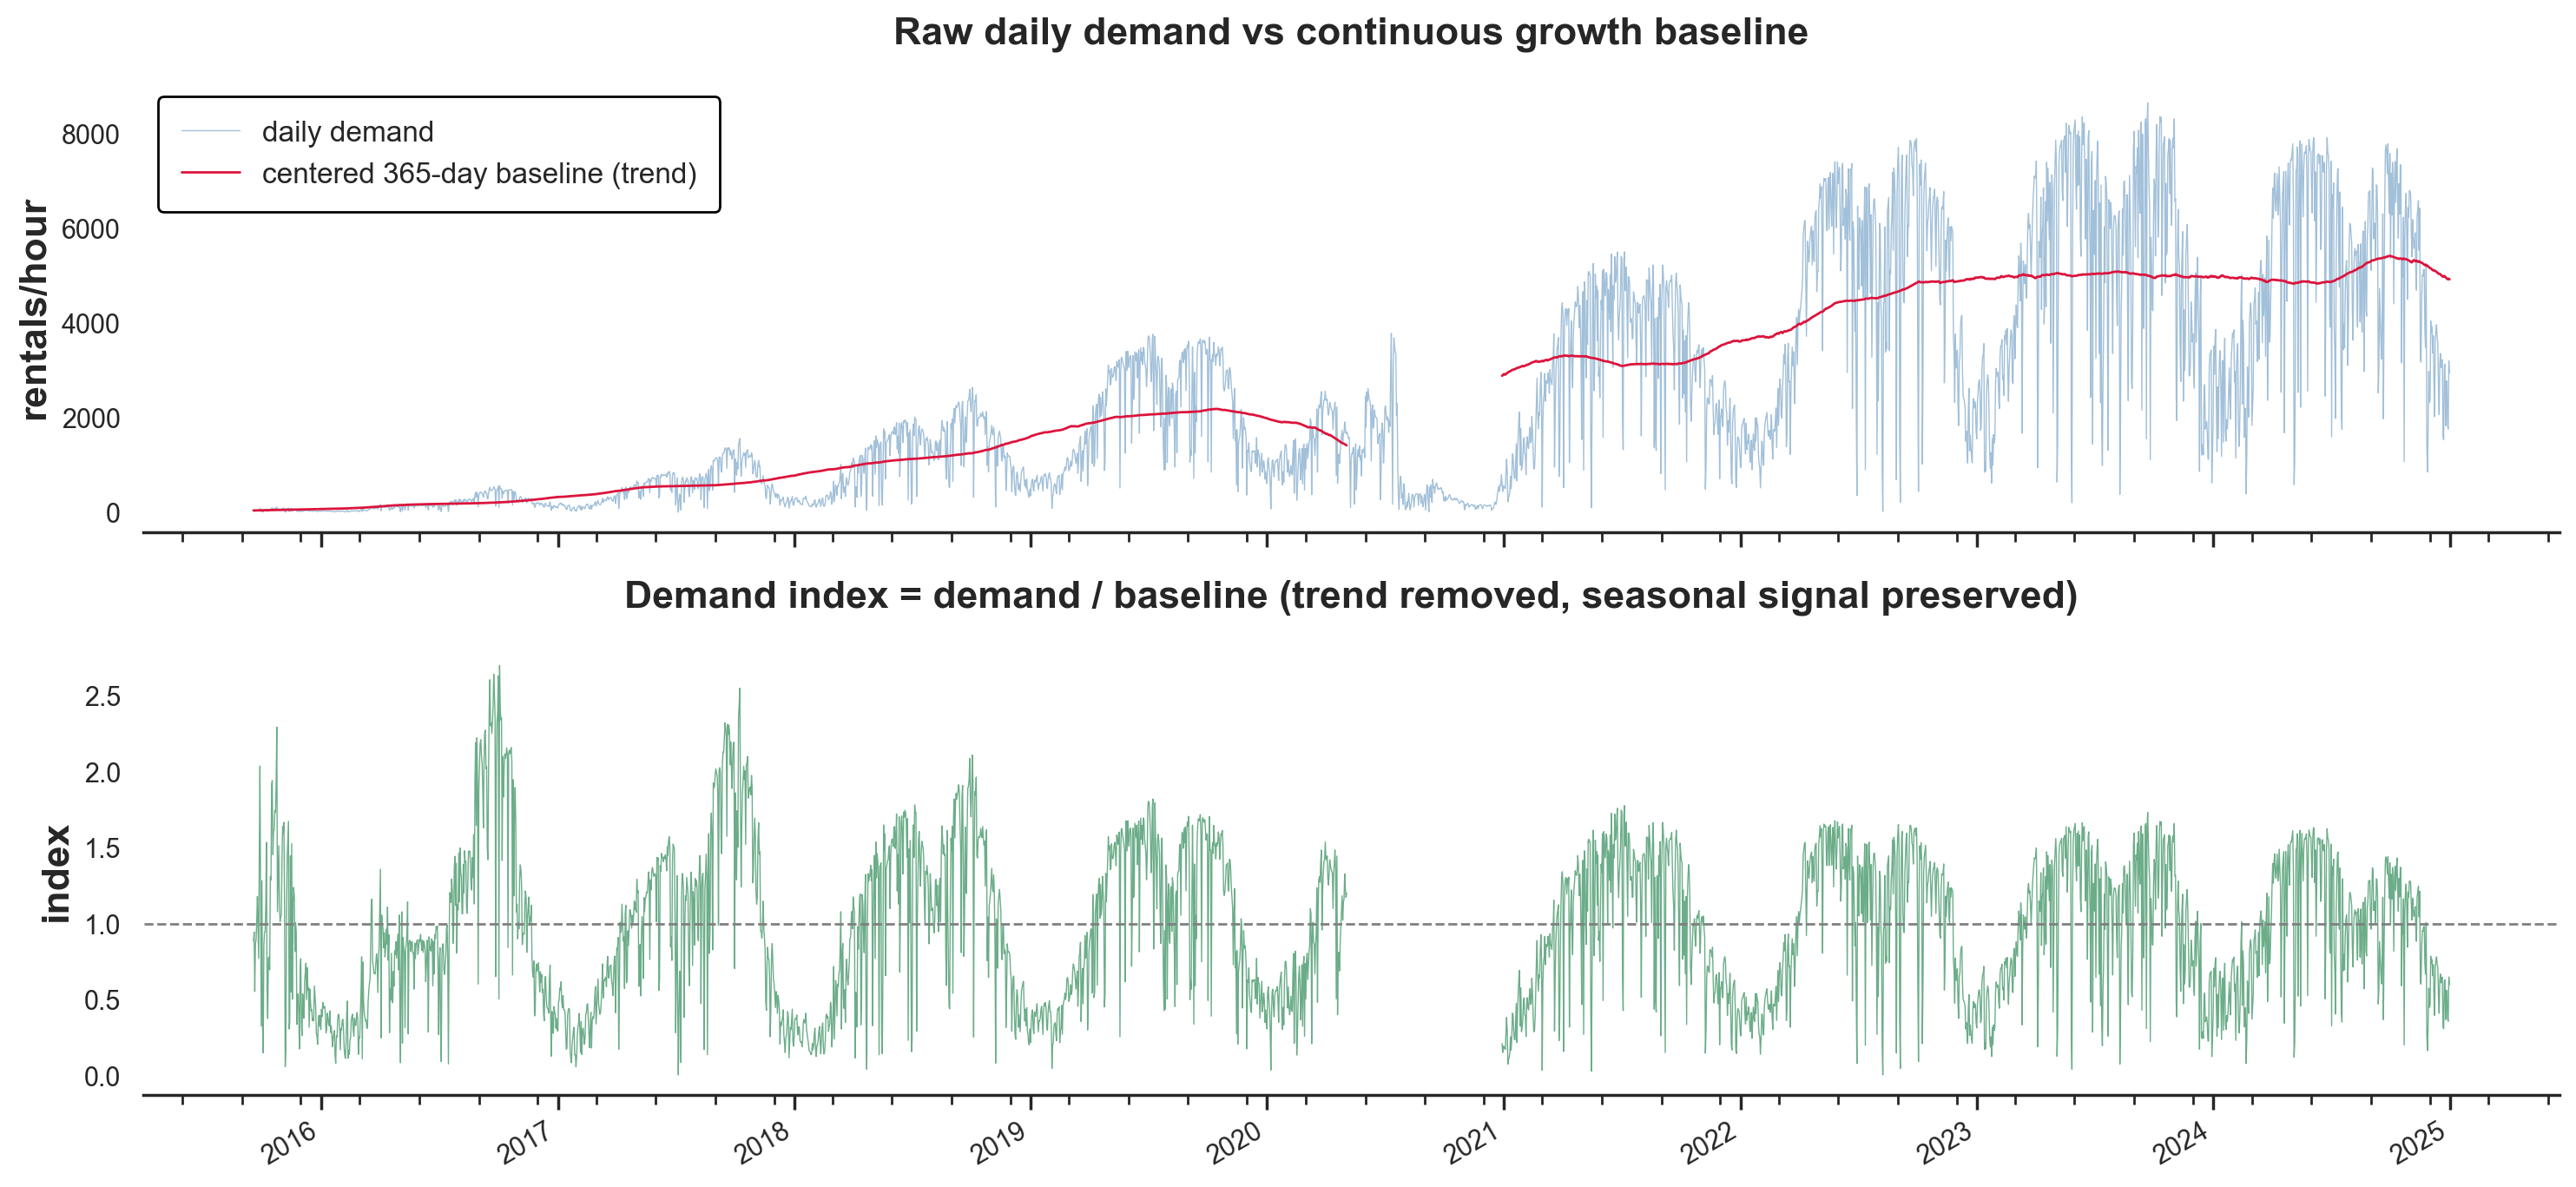

residual growth trend -> corr(time, index)=0.0274 vs corr(time, raw demand)=0.548


In [7]:
fig, axes = seasonal.plot_baseline_and_index(full, demand_index, lang=lang)
plt.show()

corr_idx, corr_raw = seasonal.time_index_correlations(full, demand_index, TARGET)
msg = lang({
    'trend': 'tendência residual de crescimento -> corr(tempo, índice)',
    'vs': 'vs corr(tempo, demanda bruta)',
})
print(f'{msg["trend"]}={corr_idx:.4f} {msg["vs"]}={corr_raw:.3f}')


In [8]:
mv_df, meta = seasonal.build_analysis_frame(full, demand_index, TARGET)
msg = lang({'frame': 'quadro de análise', 'cols': 'colunas de análise', 'rows': 'linhas'})
print(f'{msg["frame"]}: {len(mv_df):,} {msg["rows"]}')
print(f'{msg["cols"]}:', list(mv_df.columns))


analysis frame: 75,304 rows
analysis columns: ['Rented Bike Count', 'Hour', 'Temperature(C)', 'Humidity(%)', 'Wind speed (m/s)', 'Dew point temperature(C)', 'Solar Radiation (MJ/m2)', 'Sunshine (hr)', 'Cloud Cover (oktas)', 'Ground Temp(C)', 'Visibility (10m)', 'DayNumberOnWeek', 'Seasons', 'Holiday', 'Time_Period', 'Weekday', 'WeekStatus', 'Rush_Hour', 'Rush_Period', 'Rainfall Cat', 'Snowfall Cat', 'Sunshine Cat', 'Cloud Cover Cat', 'Month', 'is_anomalous_2020']


### Seasonal Pattern Recurrence Across Years (Validation of Intuition)

The hypothesis that a repeatable seasonal structure remains after removing the level is evaluated by overlapping the monthly profiles of each meteorological year (Dec→Nov). A broad hierarchy is preserved: lower indices below the base are observed in winter, a recovery is observed in spring, and higher levels are observed in warm months and early autumn. Thus, seasonal continuity is maintained without the winter being divided by the 1st/Jan border.

However, the overlap should not be interpreted as annual invariance. Differences in amplitude are visible between the curves, especially in September and October, and the years associated with anomalies or edges have partial coverage. Therefore, the **general seasonal format recurrence** was confirmed, but not the equality of profiles nor an exclusively climatic causal relationship.


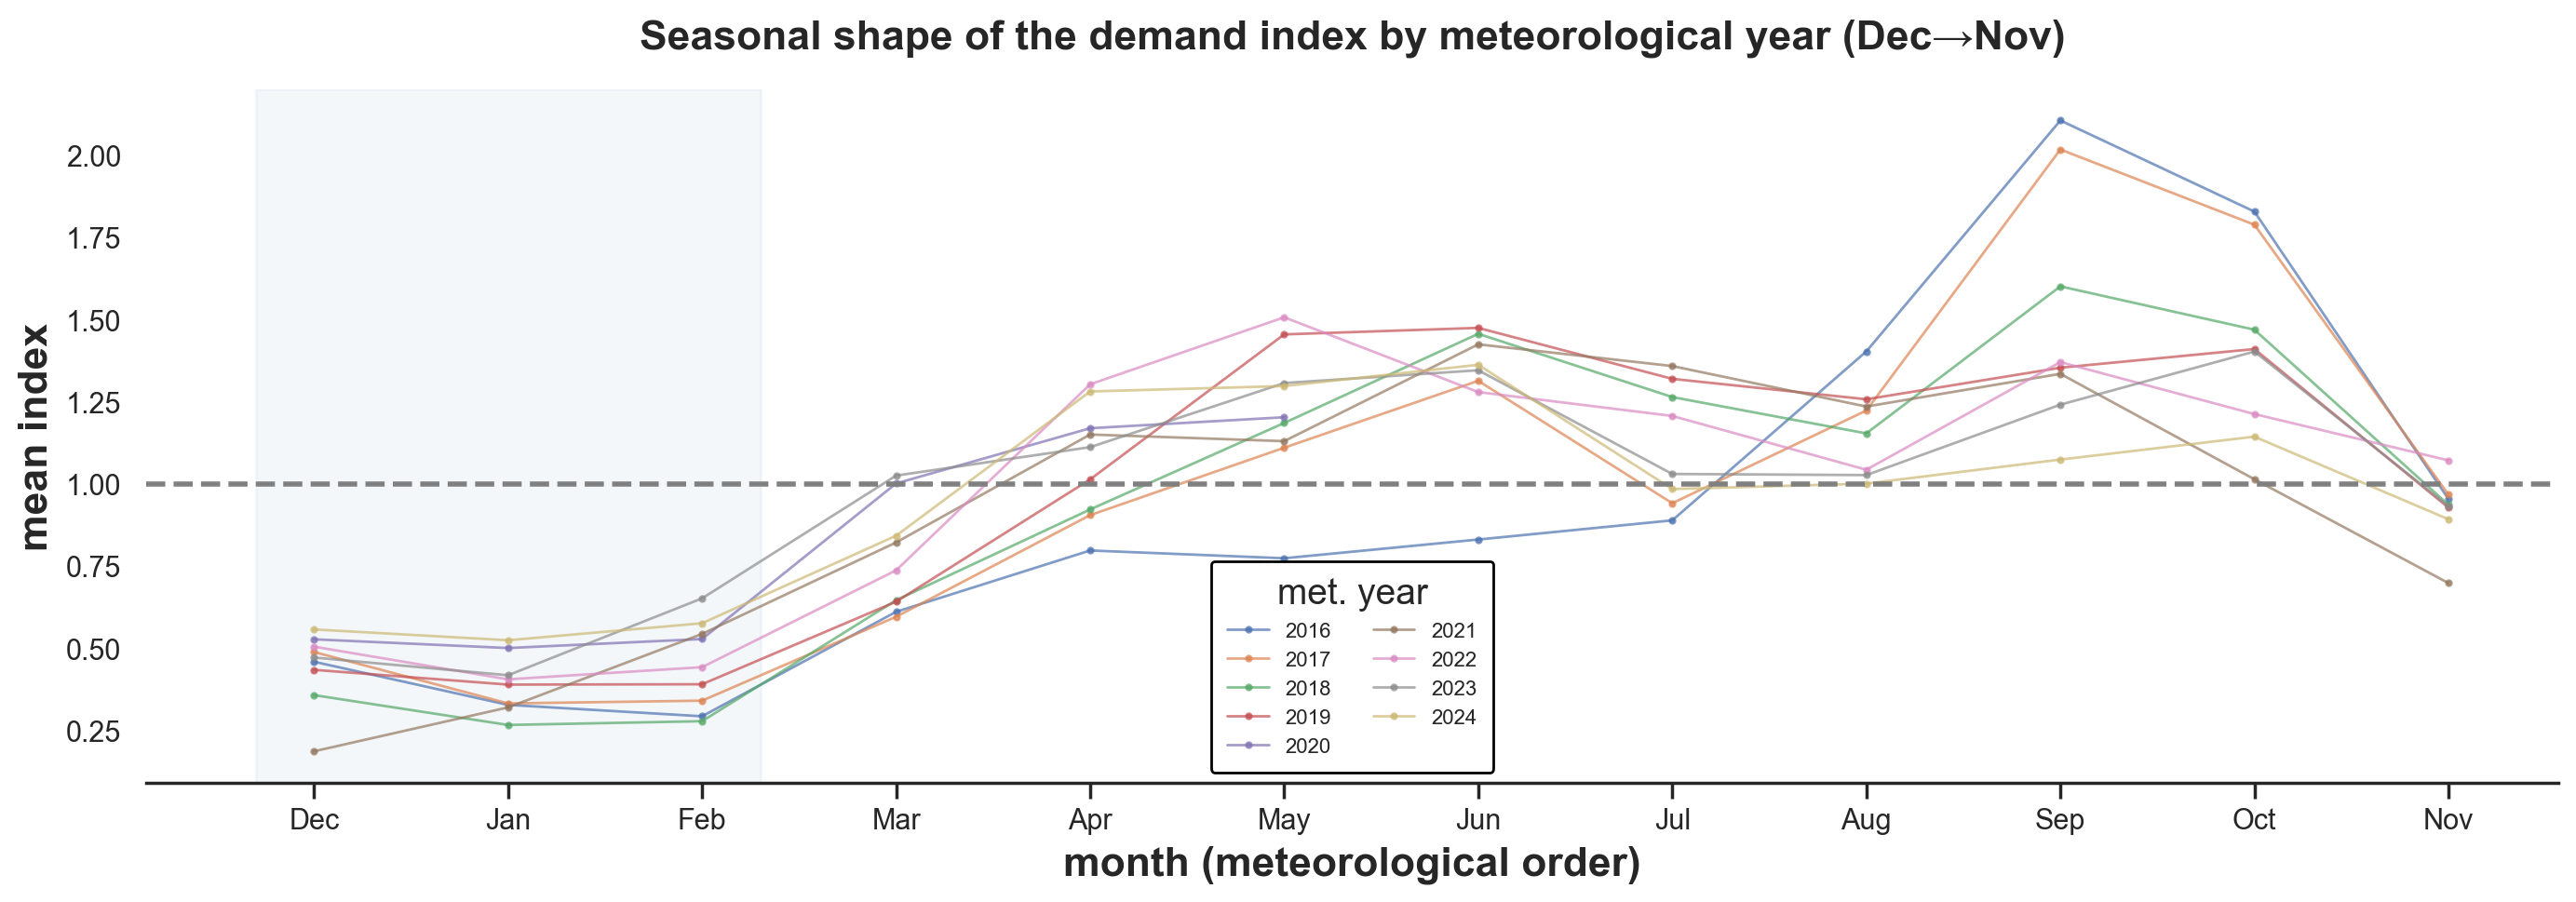

In [9]:
fig, ax = seasonal.plot_seasonal_shape_by_met_year(full, demand_index, lang=lang)
plt.show()


> **Trend Demand Insights:**
>
> The linear dependence on time was reduced from `corr(time, raw demand) = 0.548` to `corr(time, index) = 0.0274`. A strong removal of the linear trend was demonstrated, but the absence of all residual or non-linear trends was not proven.
>
> The index was defined for **75,304 of 81,018 lines (92.9%)**. The **5,714 undefined lines** were concentrated in the anomalous window of 2020, in which less than 180 non-anomalous days were available for certain centered windows. Consequently, the 2020 and 2021 summaries were affected by partial coverage.
>
> In the complete and non-anomalous meteorological years, annual means close to 1 were obtained (approximately `0.943–1.008`), which is consistent with the removal of the growth level. The values of 2015 and 2025 should not be compared directly, as they were calculated with fragments of the series' extremes.
>
> A broad seasonal pattern was preserved: relative low levels were observed in winter and higher levels were observed in warm months and early autumn. Since amplitude differences remained between years, especially in September–October, only the stability of the general form was sustained.
>
> The following analyses should be interpreted as associations with the **demand relative to the moving baseline**, conditioned to the available coverage. Causal effects were not identified, and an operational transformation for real-time prediction was not produced.


## 3. PhiK Correlation and Significance

The coefficient $\phi_K$ is employed to evaluate associations between interval, ordinal, and categorical variables under a common metric. Interval variables are internally discretized, and linear or nonlinear dependencies can be captured. The formulation and procedure for significance were proposed by [Baak et al. (2020)](https://doi.org/10.1016/j.csda.2020.107043).

Unlike the Pearson correlation, negative values and direction are not produced by $\phi_K$. The intensity is limited to the interval $[0, 1]$: absence of association is represented by 0, and complete association is represented by 1. In this notebook, values below 0.10 are treated as negligible, values between 0.10 and 0.30 as weak, values between 0.30 and 0.50 as moderate, values between 0.50 and 0.70 as relatively strong, values between 0.70 and 0.90 as strong, and values above 0.90 as very strong. These intervals are used only as descriptive conventions, not as universal inferential thresholds.

To prevent the historical growth of the operation from dominating the analysis, the **detrended index** constructed in Section 2 is used as the target. `Sunshine (hr)`, `Cloud Cover (oktas)`, and `Ground Temp(C)` are informed to the library as interval variables through `PHIK_INTERVAL_COLS`; the remaining variables are treated according to the representation received by the calculation.

A sample of **2,500 lines**, formed by 250 observations per year-calendar, is selected in a stratified and reproducible manner. The cost of the complete matrix and the hybrid evaluation of significance is reduced by this sampling, but some sampling variability and dependence on discretization are introduced. Since the same weight is assigned to each year, the coefficients now represent a balanced distribution by year, and not the original frequency of all observations. Thus, the results are used as exploratory diagnostics, and not as immutable estimates for the entire population.

The strength of the association is separated from its statistical evidence. A small coefficient can receive high significance when independence is clearly rejected, while a high coefficient can be unstable in an insufficient sample. Causality, direction of effect, and predictive gain outside the sample are not identified by this analysis.


PhiK on 2,500 rows (stratified by year)


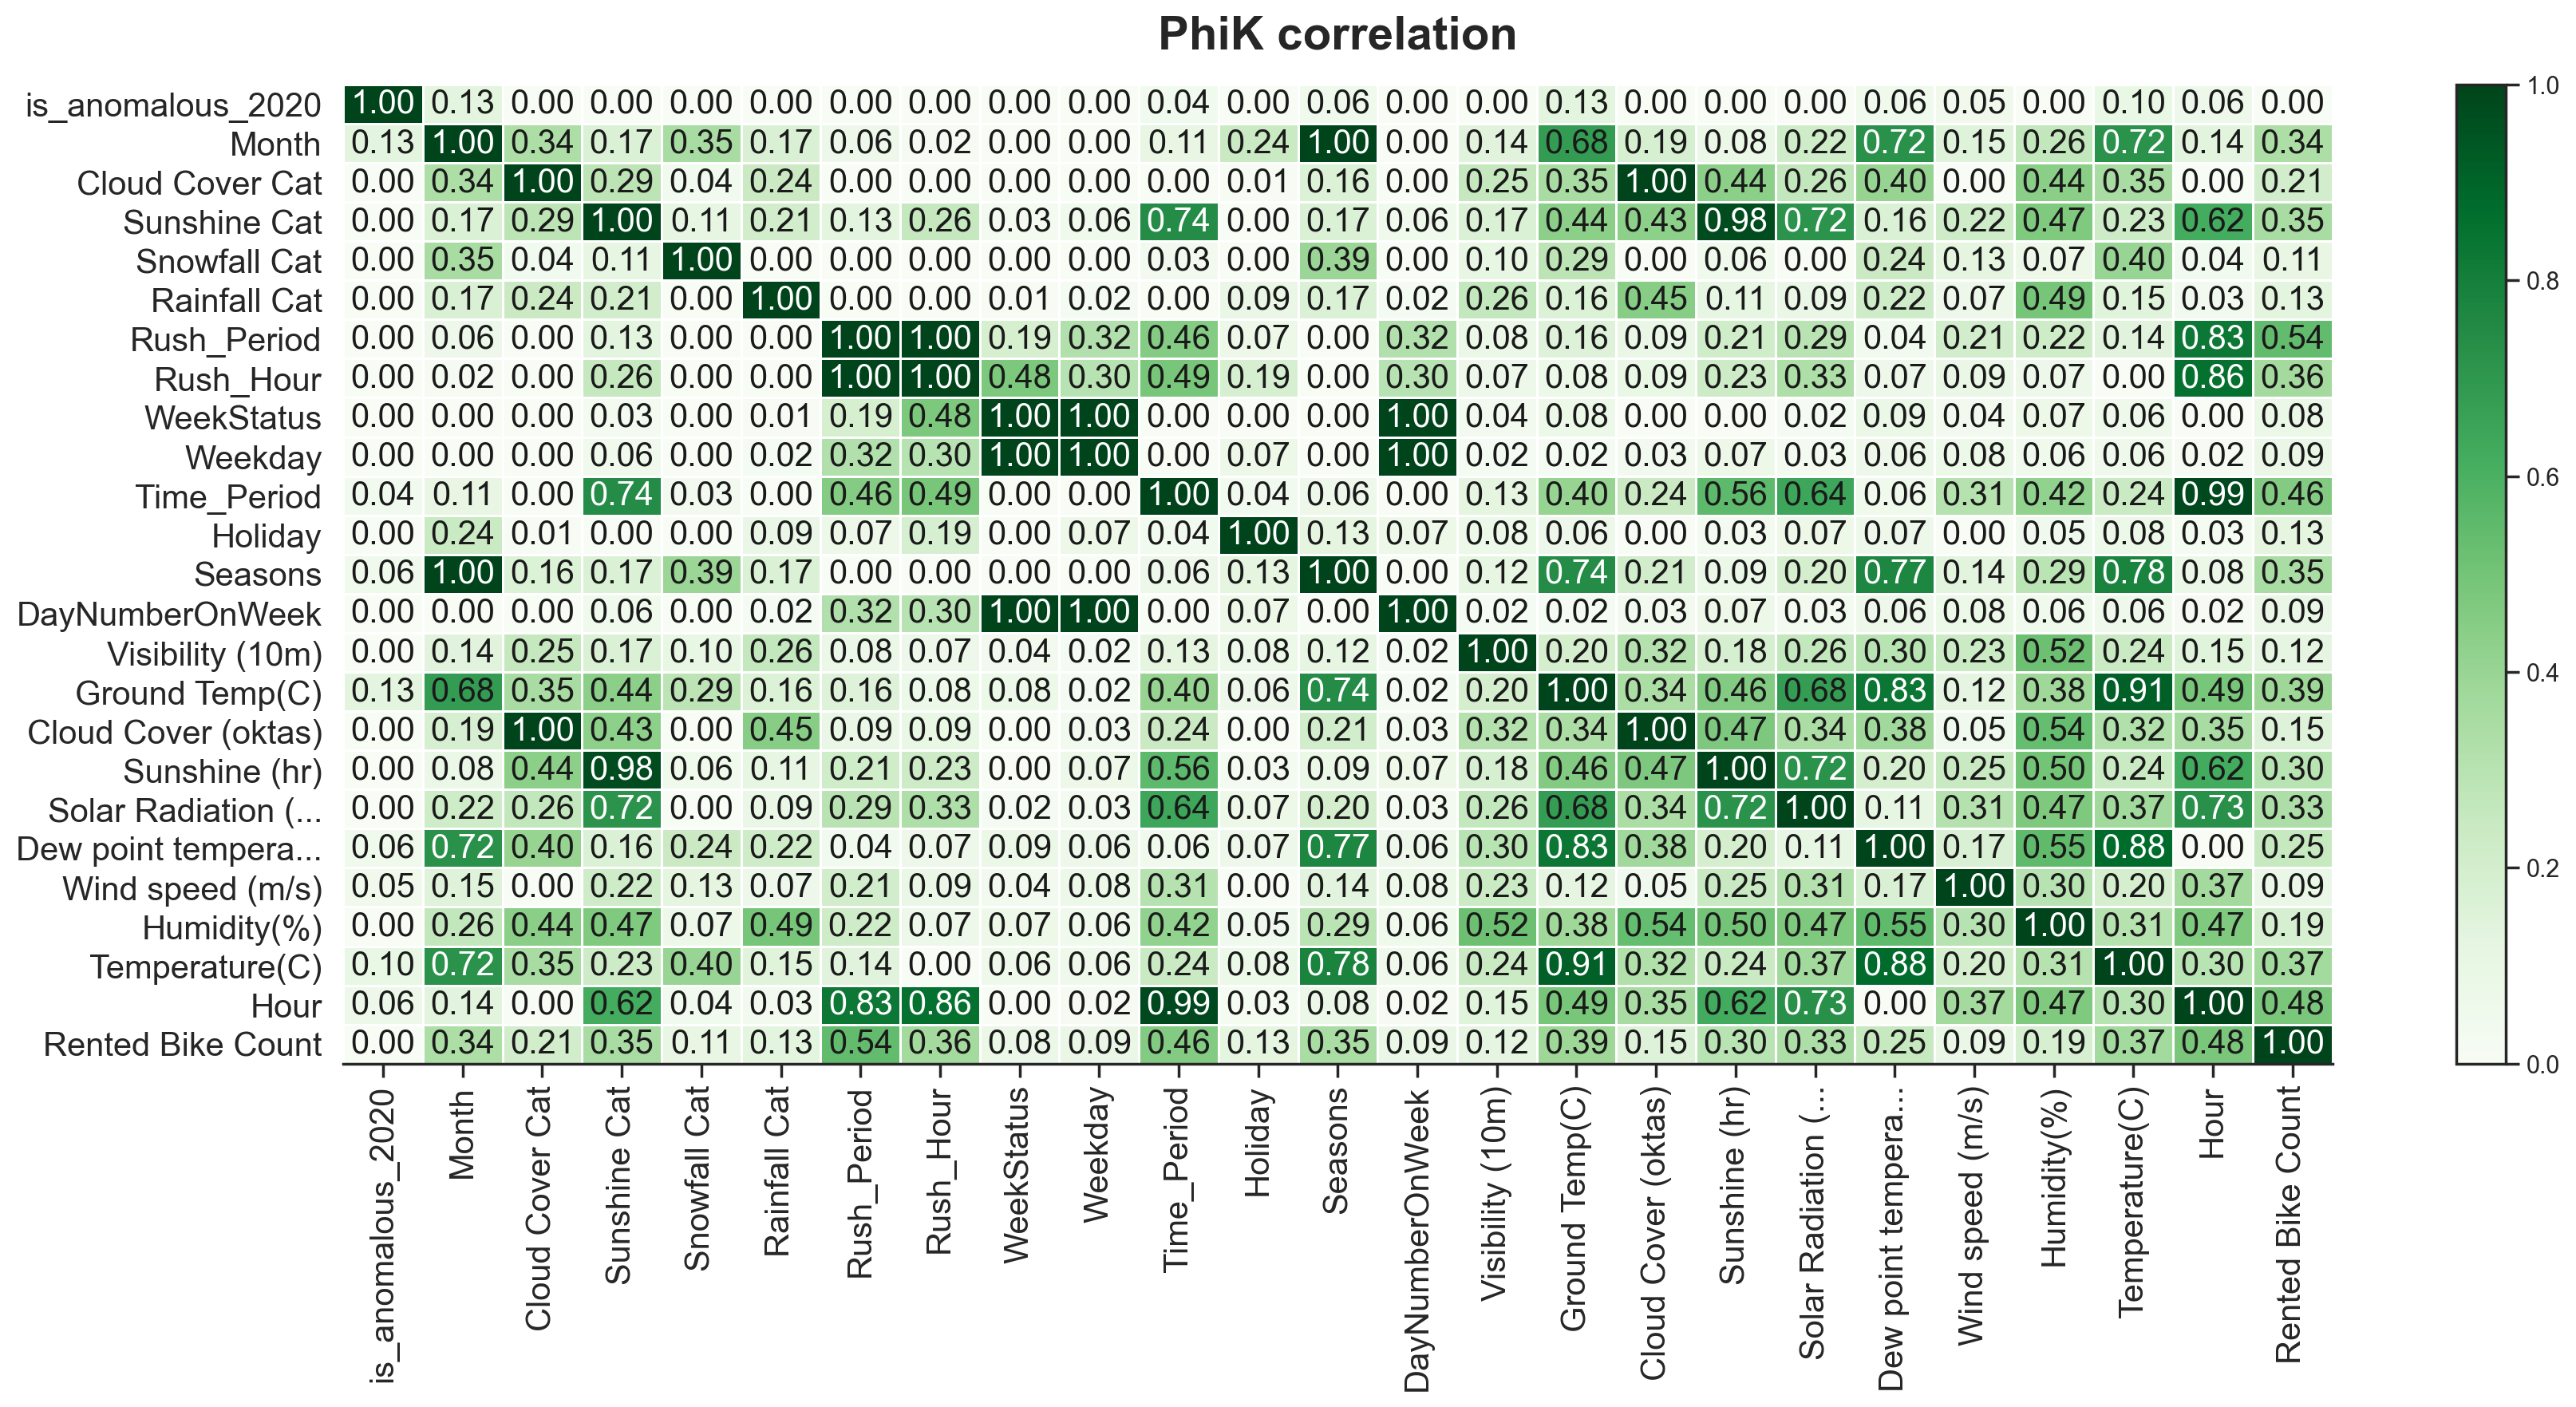

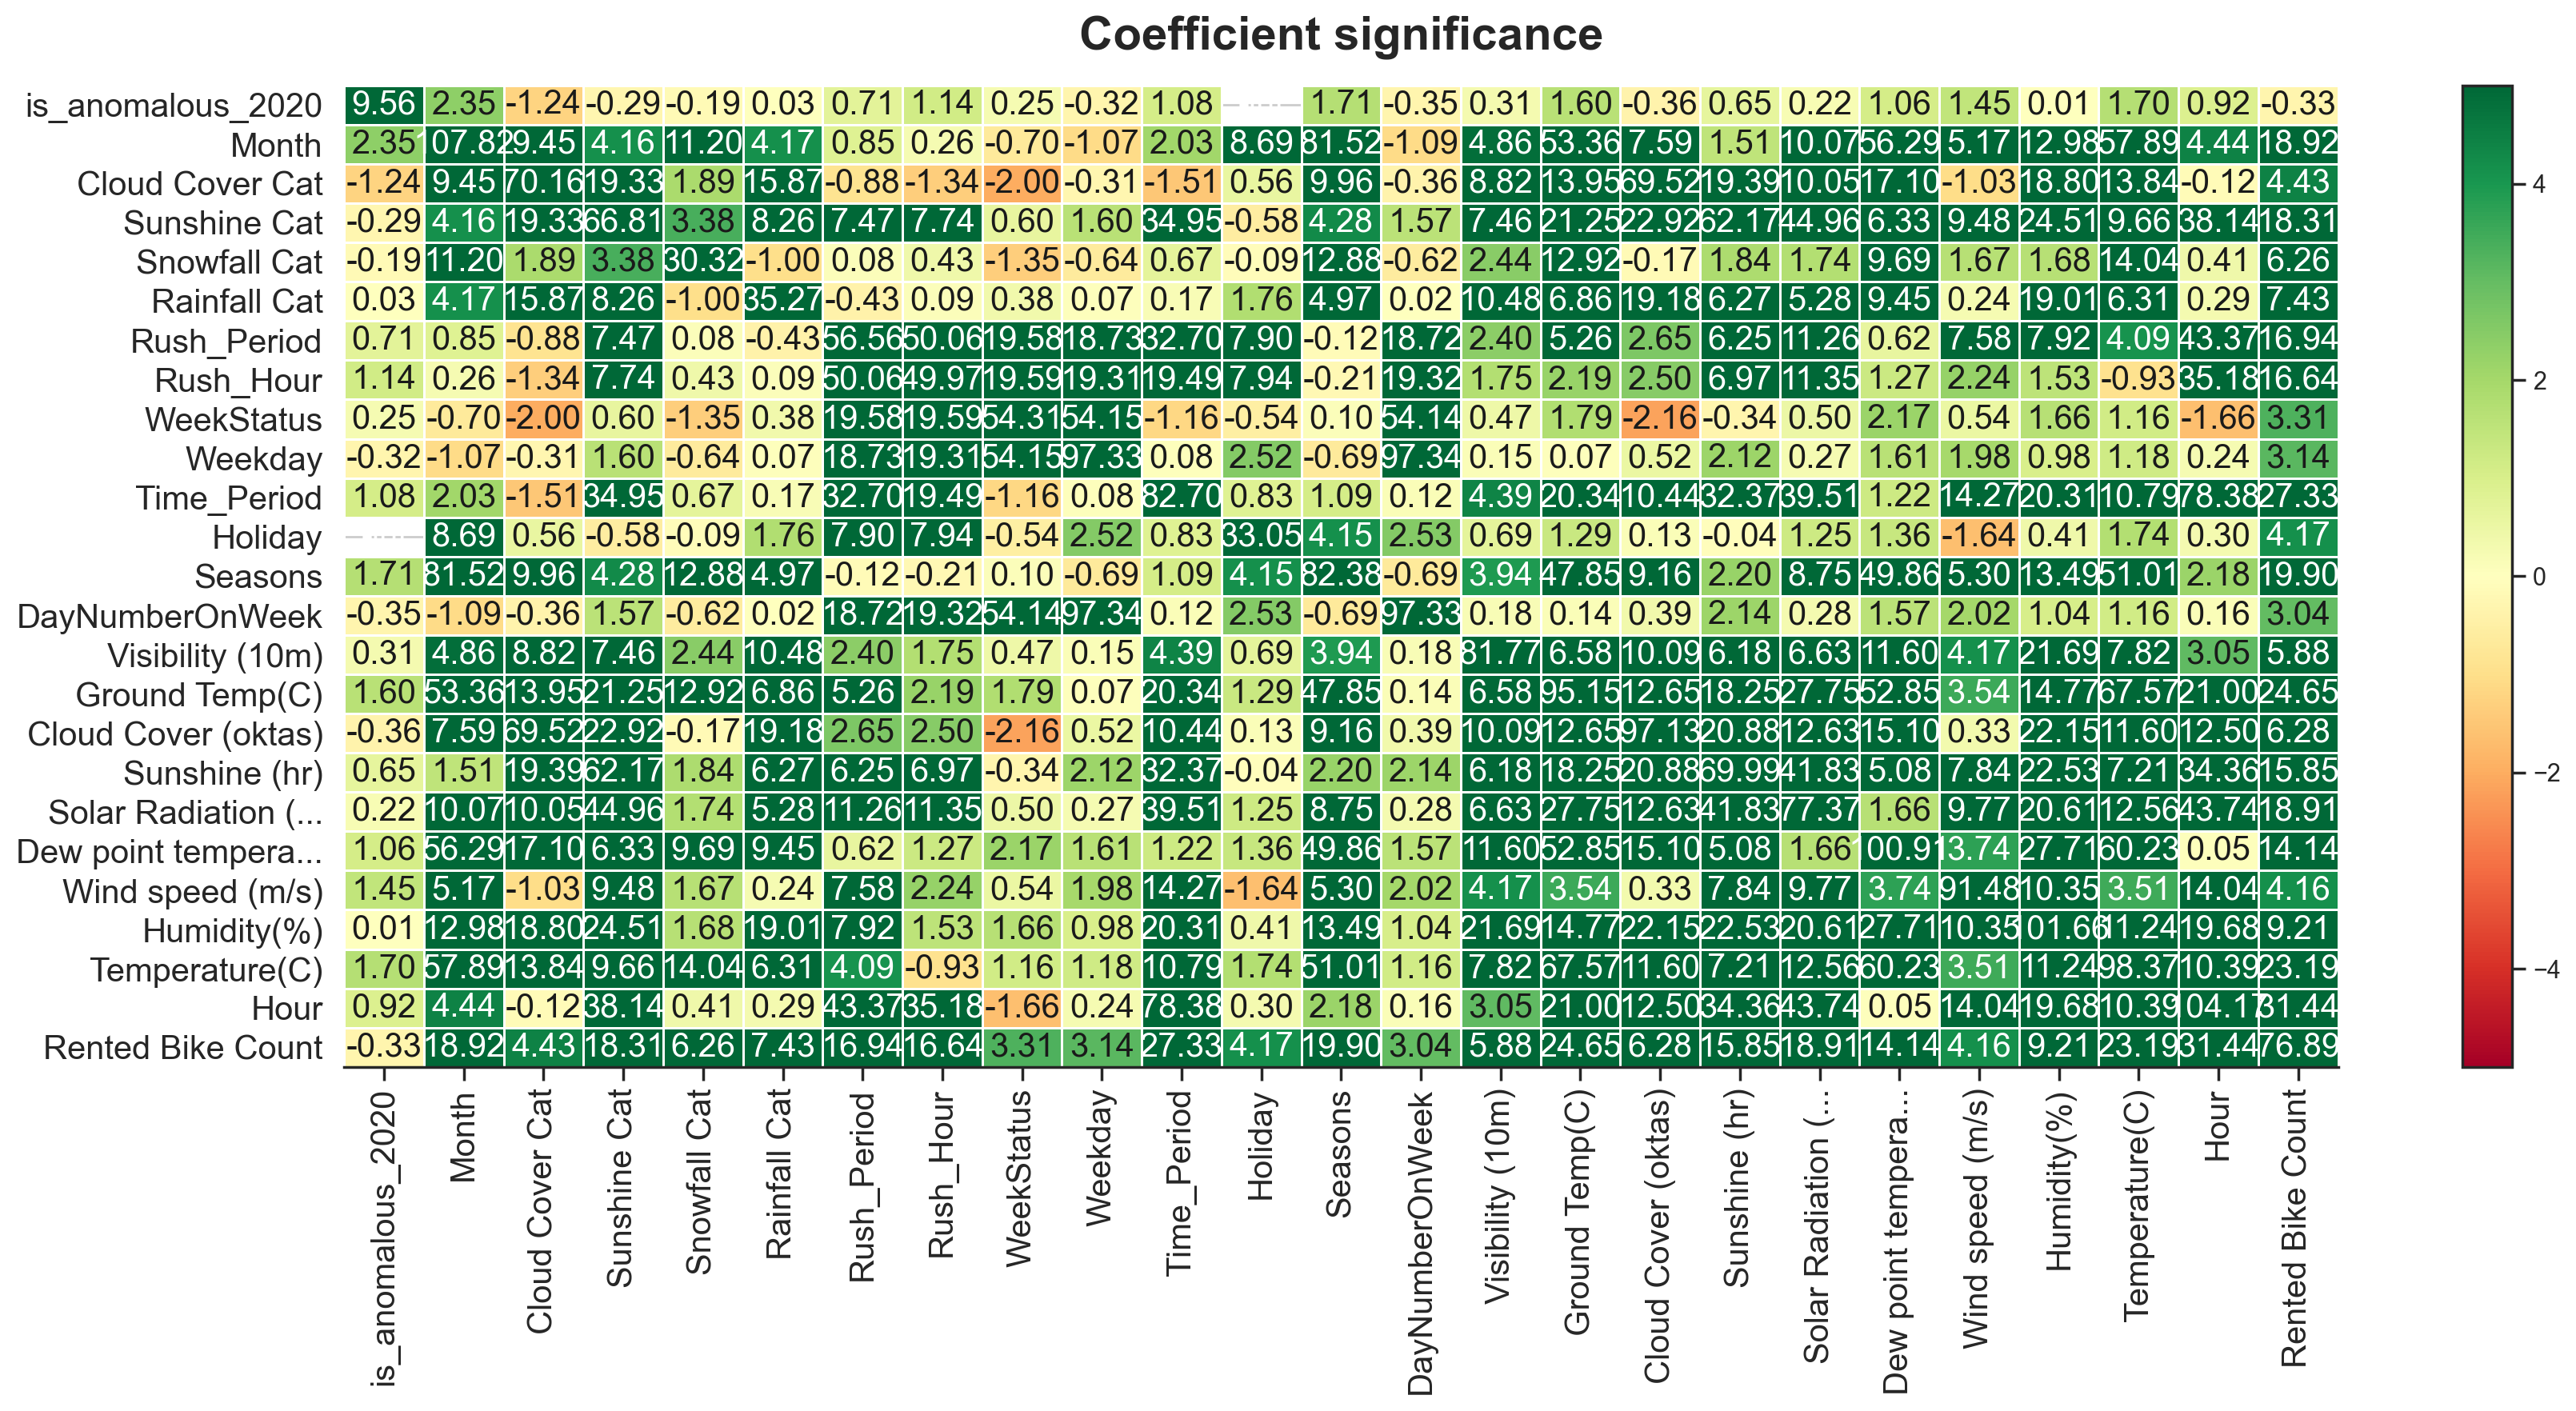

In [10]:
phik_sample = fs.stratified_sample_by(mv_df, meta['Year'], 250)
msg = lang({'phik_on': 'phik em', 'rows_strat': 'linhas (estratificado por ano)'})
print(f'{msg["phik_on"]} {len(phik_sample):,} {msg["rows_strat"]}')

phik_pairs, phik_matrix, phik_sig = fs.build_phik_significance_df(
    phik_sample, return_matrices=True)
fs.plot_phik_matrix(phik_matrix_df=phik_matrix, significance_matrix_df=phik_sig, lang=lang)
plt.show()


The significance of $\phi_K$ is returned as a one-tailed Z-value for the independence hypothesis test. The threshold `Z ≥ 3`, used as the default by the library report, is adopted as substantial statistical evidence. Magnitude and significance are examined jointly because a strong association and rejection of independence represent different properties. [Official PhiK documentation](https://phik.readthedocs.io/en/latest/phik.html)

The following table retains only the pairs for which `phik ≥ 0.50` and `significance ≥ 3`. Each combination is presented only once through `var1` and `var2`, and the results are ordered from the strongest to the weakest association.


In [11]:
# Associações fortes e estatisticamente significativas entre pares de variáveis
PHIK_THRESHOLD = 0.50
SIGNIFICANCE_THRESHOLD = 3.0  # valor-Z unilateral (padrão do relatório PhiK)

significant_phik_pairs = fs.filter_significant_phik_pairs(
    phik_pairs, PHIK_THRESHOLD, SIGNIFICANCE_THRESHOLD)

phik_labels = lang({'significance': 'significância'})
display(fs.localize_phik_report(significant_phik_pairs, lang=lang).style.format(
    {'phik': '{:.3f}', phik_labels['significance']: '{:.2f} σ'}))


,Variable 1,Variable 2,phik,significance
0,DayNumberOnWeek,Weekday,1.000,97.34 σ
1,Seasons,Month,1.000,81.52 σ
2,Cloud Cover (oktas),Cloud Cover Cat,1.000,69.52 σ
3,Weekday,WeekStatus,1.000,54.15 σ
4,DayNumberOnWeek,WeekStatus,1.000,54.14 σ
5,Rush_Hour,Rush_Period,1.000,50.06 σ
6,Hour,Time_Period,0.986,78.38 σ
7,Sunshine (hr),Sunshine Cat,0.976,62.17 σ
8,Temperature(C),Ground Temp(C),0.913,67.57 σ
9,Temperature(C),Dew point temperature(C),0.877,60.23 σ


Next, the analysis is restricted to pairs containing the detrended target variable. In this framework, no magnitude cut is applied, so that moderate or weak associations with statistical evidence are also preserved for interpretation.


In [12]:
# Maiores associações com o índice de demanda (des-tendenciado)
demand_pairs = fs.phik_pairs_with_target(phik_pairs, TARGET, lang=lang)
display(demand_pairs.head(30))


,Other variable,phik,significance
0,Rush_Period,0.541510,16.943929
1,Hour,0.480698,31.443574
2,Time_Period,0.457938,27.334203
3,Ground Temp(C),0.385456,24.647915
4,Temperature(C),0.368251,23.186982
5,Rush_Hour,0.363831,16.641657
6,Sunshine Cat,0.354717,18.313553
7,Seasons,0.347142,19.896906
8,Month,0.339824,18.915786
9,Solar Radiation (MJ/m2),0.332745,18.905449


> **Insights from PhiK Analysis**
>
> After applying the combined filter of magnitude and significance, **33 pairs** were retained with `phik ≥ 0.50` and `Z ≥ 3`. The largest associations were observed mainly in variables derived from the same information: values equal to 1 were obtained for `DayNumberOnWeek`–`Weekday`, `Seasons`–`Month`, `Cloud Cover (oktas)`–`Cloud Cover Cat`, `Weekday`–`WeekStatus`, `DayNumberOnWeek`–`WeekStatus`, and `Rush_Hour`–`Rush_Period`. Associations close to 1 were also obtained for `Hour`–`Rush_Period` (`0.825`), `Hour`–`Time_Period`, `Sunshine (hr)`–`Sunshine Cat`, and `Hour`–`Rush_Hour`. These relationships are interpreted as redundancies introduced by feature engineering, and not as independent discoveries.
>
> A second redundant structure was observed between the thermal measurements. Values between `0.828` and `0.913` were obtained between `Temperature(C)`, `Ground Temp(C)`, and `Dew point temperature(C)`, while relevant associations were also observed with `Month` and `Seasons`. It was indicated, thus, an overlap of physical information and seasonality, but an automatic exclusion was not justified solely by the bivariate association.
>
> Only one pair formed with the target achieved `phik ≥ 0.50`: `Rush_Period` (`0.542`). The largest associations with the detrended index were obtained for `Rush_Period` (`0.542`), `Hour` (`0.481`), `Time_Period` (`0.458`), `Ground Temp(C)` (`0.385`), and `Temperature(C)` (`0.368`), all accompanied by high Z-values. Since `Rush_Period` is a deterministic function of the hour — its `phik` values equal to `1.000` with `Rush_Hour` and `0.825` with `Hour` confirm this dependence —, its association with the target reflects the same peak hour signal, and not an independent information. It was evidenced, thus, that a relevant signal is contained by the peak period, by the hour, by the day period, and by the thermal conditions, although a strong explanation of the relative demand is not produced by an isolated variable.
>
> As a decision of this project, a manual removal of variables will not be executed based solely on PhiK. All variables will be maintained as candidates, and the final choice will be delegated to the optimization process within the pipeline. Thus, conditional interactions and specific utility for each estimator can be preserved even when high or low bivariate associations have been observed.
>
> In the function `RegressionOptimizer.get_feature_selection`, defined in `src/optimizer.py`, an alternative compatible with the estimator family is sampled. `NoSelector` is implemented as `passthrough`; by `SelectKBest`, between 6 and 22 variables are retained with `mutual_info_regression`; by `RFE`, between 6 and 18 variables are selected recursively; by `SelectFromModel`, a maximum between 8 and 24 variables is imposed from the importance of the estimator and the sampled threshold; and by `SequentialFeatureSelector`, between 6 and 14 variables are selected in the *backward* sense with internal cross-validation. Thus, the very absence of selection is also compared as a modeling hypothesis.
>
> Not all selectors are offered to all estimators. For example, only `NoSelector` and `SelectKBest` are available for `HistGradientBoostingRegressor` due to compatibility and cost restrictions; besides, `NoSelector` is rejected when a high-dimensional preprocessing is chosen. The final decision must, therefore, be read as a result of the combination of estimator, transformation, selector, and temporal validation, and not as a universal ranking of features.
>
> If `NoSelector` is chosen, deterministic redundancies may remain in the model and importance may be distributed between equivalent representations. For interpretation purposes, these variables should be analyzed in semantic groups. Causality, direction of effect, and stability outside the sample were not demonstrated by the PhiK matrix.


## 4. Collinearity of Temperature Variables (VIF)

The linear multicolinearity between six continuous meteorological measures was examined: air temperature, dew point, soil temperature, humidity, solar radiation, and wind speed. The diagnosis was limited to this subset, as physical and seasonal overlaps were expected; therefore, a global evaluation of all dataset features was not produced.

For each feature $X_j$, a linear auxiliary regression of $X_j$ against the remaining features was fitted, with an intercept, and $VIF_j = 1/(1-R_j^2)$ was calculated. The value of $R_j^2$ from this regression was also presented as `R2_auxiliar`, to explicitly show the portion of each predictor's variance linearly reconstructed by the others. The target does not participate in this calculation: the deseasoned demand index only determines the inherited 75,304-line cutoff from `mv_df`.

A VIF of 1 represents the absence of variance inflation, while increasing values indicate greater joint linear redundancy. The ranges `< 5`, `5–10`, and `> 10` are adopted only as descriptive references. A variable should not be automatically removed because a threshold was exceeded; the sample size, inferential or predictive objective, and estimator family should also be considered. This caution regarding the mechanical use of cutoff rules was discussed by [O’Brien (2007)](https://doi.org/10.1007/s11135-006-9018-6).


In [13]:
temp_like = ['Temperature(C)', 'Dew point temperature(C)', 'Ground Temp(C)',
             'Humidity(%)', 'Solar Radiation (MJ/m2)', 'Wind speed (m/s)']
vif_df = fs.compute_vif_report(mv_df, temp_like)

print(fs.localize_vif_report(vif_df, lang=lang).to_string(index=False,
      formatters={'VIF': '{:.2f}'.format, 'R2_auxiliar': '{:.3f}'.format}))
msg = lang({'note': ('R2_auxiliar: proporção da variância da feature explicada '
                     'pela regressão auxiliar com as demais features.')})
print(f'\n{msg["note"]}')


                Variable    VIF R2_auxiliar
Dew point temperature(C) 149.86       0.993
          Temperature(C) 132.71       0.992
             Humidity(%)  26.46       0.962
          Ground Temp(C)  21.53       0.954
 Solar Radiation (MJ/m2)   4.15       0.759
        Wind speed (m/s)   1.10       0.093

Auxiliary R²: proportion of feature variance explained by the auxiliary regression on the remaining features.


> **Insights from VIF Analysis**
>
> In the specification with intercept, the highest VIFs were obtained for `Dew point temperature(C)` (`149.86`) and `Temperature(C)` (`132.71`). These values correspond to `R2_auxiliar` of `0.993` and `0.992`: more than 99% of the variance of each of these features was reconstructed linearly by the remaining set of meteorological variables. Therefore, a very intense joint redundancy was evidenced, and not just an isolated correlation between two columns.
>
> Also elevated values were obtained for `Humidity(%)` (`26.46`; $R^2=0.962$) and `Ground Temp(C)` (`21.53`; $R^2=0.954$). For `Solar Radiation (MJ/m2)` (`4.15`) and `Wind speed (m/s)` (`1.10`), no high variance inflation was indicated by the adopted descriptive bands. The observed structure is consistent with the physical dependence of dew point on temperature and humidity and with the proximity between air and ground temperatures, but the exclusive contribution of each relationship was not identified by VIF.
>
> The main consequence of high VIFs is expected in the stability of coefficients and standard errors of linear estimators: individual effects can be redistributed between redundant variables, and isolated interpretations can become fragile. However, it was not demonstrated that each variable is useless for prediction, nor that a specific exclusion would produce better performance outside the sample.
>
> As a project decision, no variable will be manually removed based solely on VIF. The six features will be maintained as candidates, and selection will be delegated to the pipeline through `SelectKBest`, `RFE`, `SelectFromModel`, `SequentialFeatureSelector`, or `NoSelector`, according to compatibility with the estimator and performance obtained in temporal validation. If `NoSelector` is chosen, coefficients and importances of thermal variables should be interpreted with caution and, when relevant, as shared information by the group.
>
> Since the target was not used in the calculation, association with detrended demand and predictive gain were not measured by this section. Only linear redundancy between predictors was diagnosed; the final utility will be established by the selection process and evaluation outside the sample.


## 5. Seasonal Hypothesis Tests (Mann-Whitney, Kruskal-Wallis, Spearman)

Two questions are evaluated regarding the deseasoned index: whether the distribution of relative demand differs between seasons and holidays, and whether a monotonic association is observed between relative demand and temperature. The significance level was set to $\alpha=0.05$, and bilateral hypotheses were adopted in two-group comparisons and the correlation test.

The index constructed in Section 2 is used as the response variable, not the raw count of bicycles. Thus, the differences are interpreted in relation to the moving baseline period, without confusing long-term growth with seasonal contrasts. Since the index distribution is asymmetric and contains extreme values, methods based on ranks are employed without requiring normality.

In the three planned seasonal comparisons and the holiday vs. non-holiday contrast, the Mann-Whitney U test of [Mann and Whitney (1947)](https://doi.org/10.1214/aoms/1177730491) is used. Under $H_0$, equal stochasticity between distributions is assumed; a difference in medians can only be taken as direct interpretation when formats and dispersions are sustained. Therefore, medians are presented as descriptive summaries, and magnitude is complemented by the bivariate correlation of ranks $r_{rb}$, calculated from U according to the formulation discussed by [Kerby (2014)](https://doi.org/10.2466/11.IT.3.1). Positive values indicate predominance of the first group named in the test, and negative values indicate predominance of the second.

For the simultaneous comparison of spring, summer, autumn, and winter, the Kruskal-Wallis test of [Kruskal and Wallis (1952)](https://doi.org/10.1080/01621459.1952.10483441) is used. The null hypothesis establishes equality between the four distributions, and its rejection indicates that at least one of them differs; the global magnitude is summarized by $\epsilon^2$. Along this test line, medians are presented in the order of spring, summer, autumn, and winter. The monotonic association between temperature and demand is evaluated by the Spearman coefficient of [Spearman (1904)](https://doi.org/10.2307/1412159), under $H_0:\rho_s=0$. Linearity and normality are not required, but causality and absence of seasonal confounding are not established.

Since six hypotheses are examined in the same exploratory family, p-values are also adjusted by the sequential procedure of [Holm (1979)](https://www.jstor.org/stable/4615733), which controls the family error without requiring independence between tests. The adjusted decision is presented separately from the nominal decision of each graph.

Although they dispense with normality, these tests do not dispense with independence between observations. Serial dependence is plausible in the 75,304 hourly observations and is not modeled by the reference distributions used; consequently, p-values may be excessively small. Inferential conclusions are treated as exploratory, and greater weight is given to effect sizes, medians, and posterior temporal validation. A formal confirmation would require aggregation by independent blocks, reblocking, or a model that explicitly represents the temporal structure.


,Test,N,Group medians,Reference,Observed statistic,Raw statistic,Effect measure,Effect size,Left critical,Right critical,p-value,Decision,Holm p-value,Holm decision
0,Mann-Whitney: Spring vs Winter,19178 / 19540,0.837 / 0.369,Normal approximation,71.442678,2.659275e+08,rank-biserial r,0.419271,-1.959964,1.959964,0.000000e+00,Reject H₀,0.000000e+00,Reject H₀
1,Mann-Whitney: Summer vs Autumn,17594 / 18992,1.023 / 1.070,Normal approximation,-3.490913,1.635491e+08,rank-biserial r,-0.021090,-1.959964,1.959964,4.813738e-04,Reject H₀,4.813738e-04,Reject H₀
2,Mann-Whitney: Summer vs Winter,17594 / 19540,1.023 / 0.369,Normal approximation,91.111197,2.658695e+08,rank-biserial r,0.546712,-1.959964,1.959964,0.000000e+00,Reject H₀,0.000000e+00,Reject H₀
3,Kruskal-Wallis: All seasons,75304,0.837 / 1.023 / 1.070 / 0.369,Chi-square(df=3),11573.229561,1.157323e+04,epsilon-squared,0.153655,NaN,7.814728,0.000000e+00,Reject H₀,0.000000e+00,Reject H₀
4,Spearman: Demand vs Temperature,75304,NaN,t(df=75302),159.197602,5.018091e-01,Spearman rho,0.501809,-1.959995,1.959995,0.000000e+00,Reject H₀,0.000000e+00,Reject H₀
5,Mann-Whitney: Holiday vs Non-Holiday,3745 / 71559,0.449 / 0.730,Normal approximation,-16.060552,1.131666e+08,rank-biserial r,-0.155437,-1.959964,1.959964,4.822412e-58,Reject H₀,9.644823e-58,Reject H₀


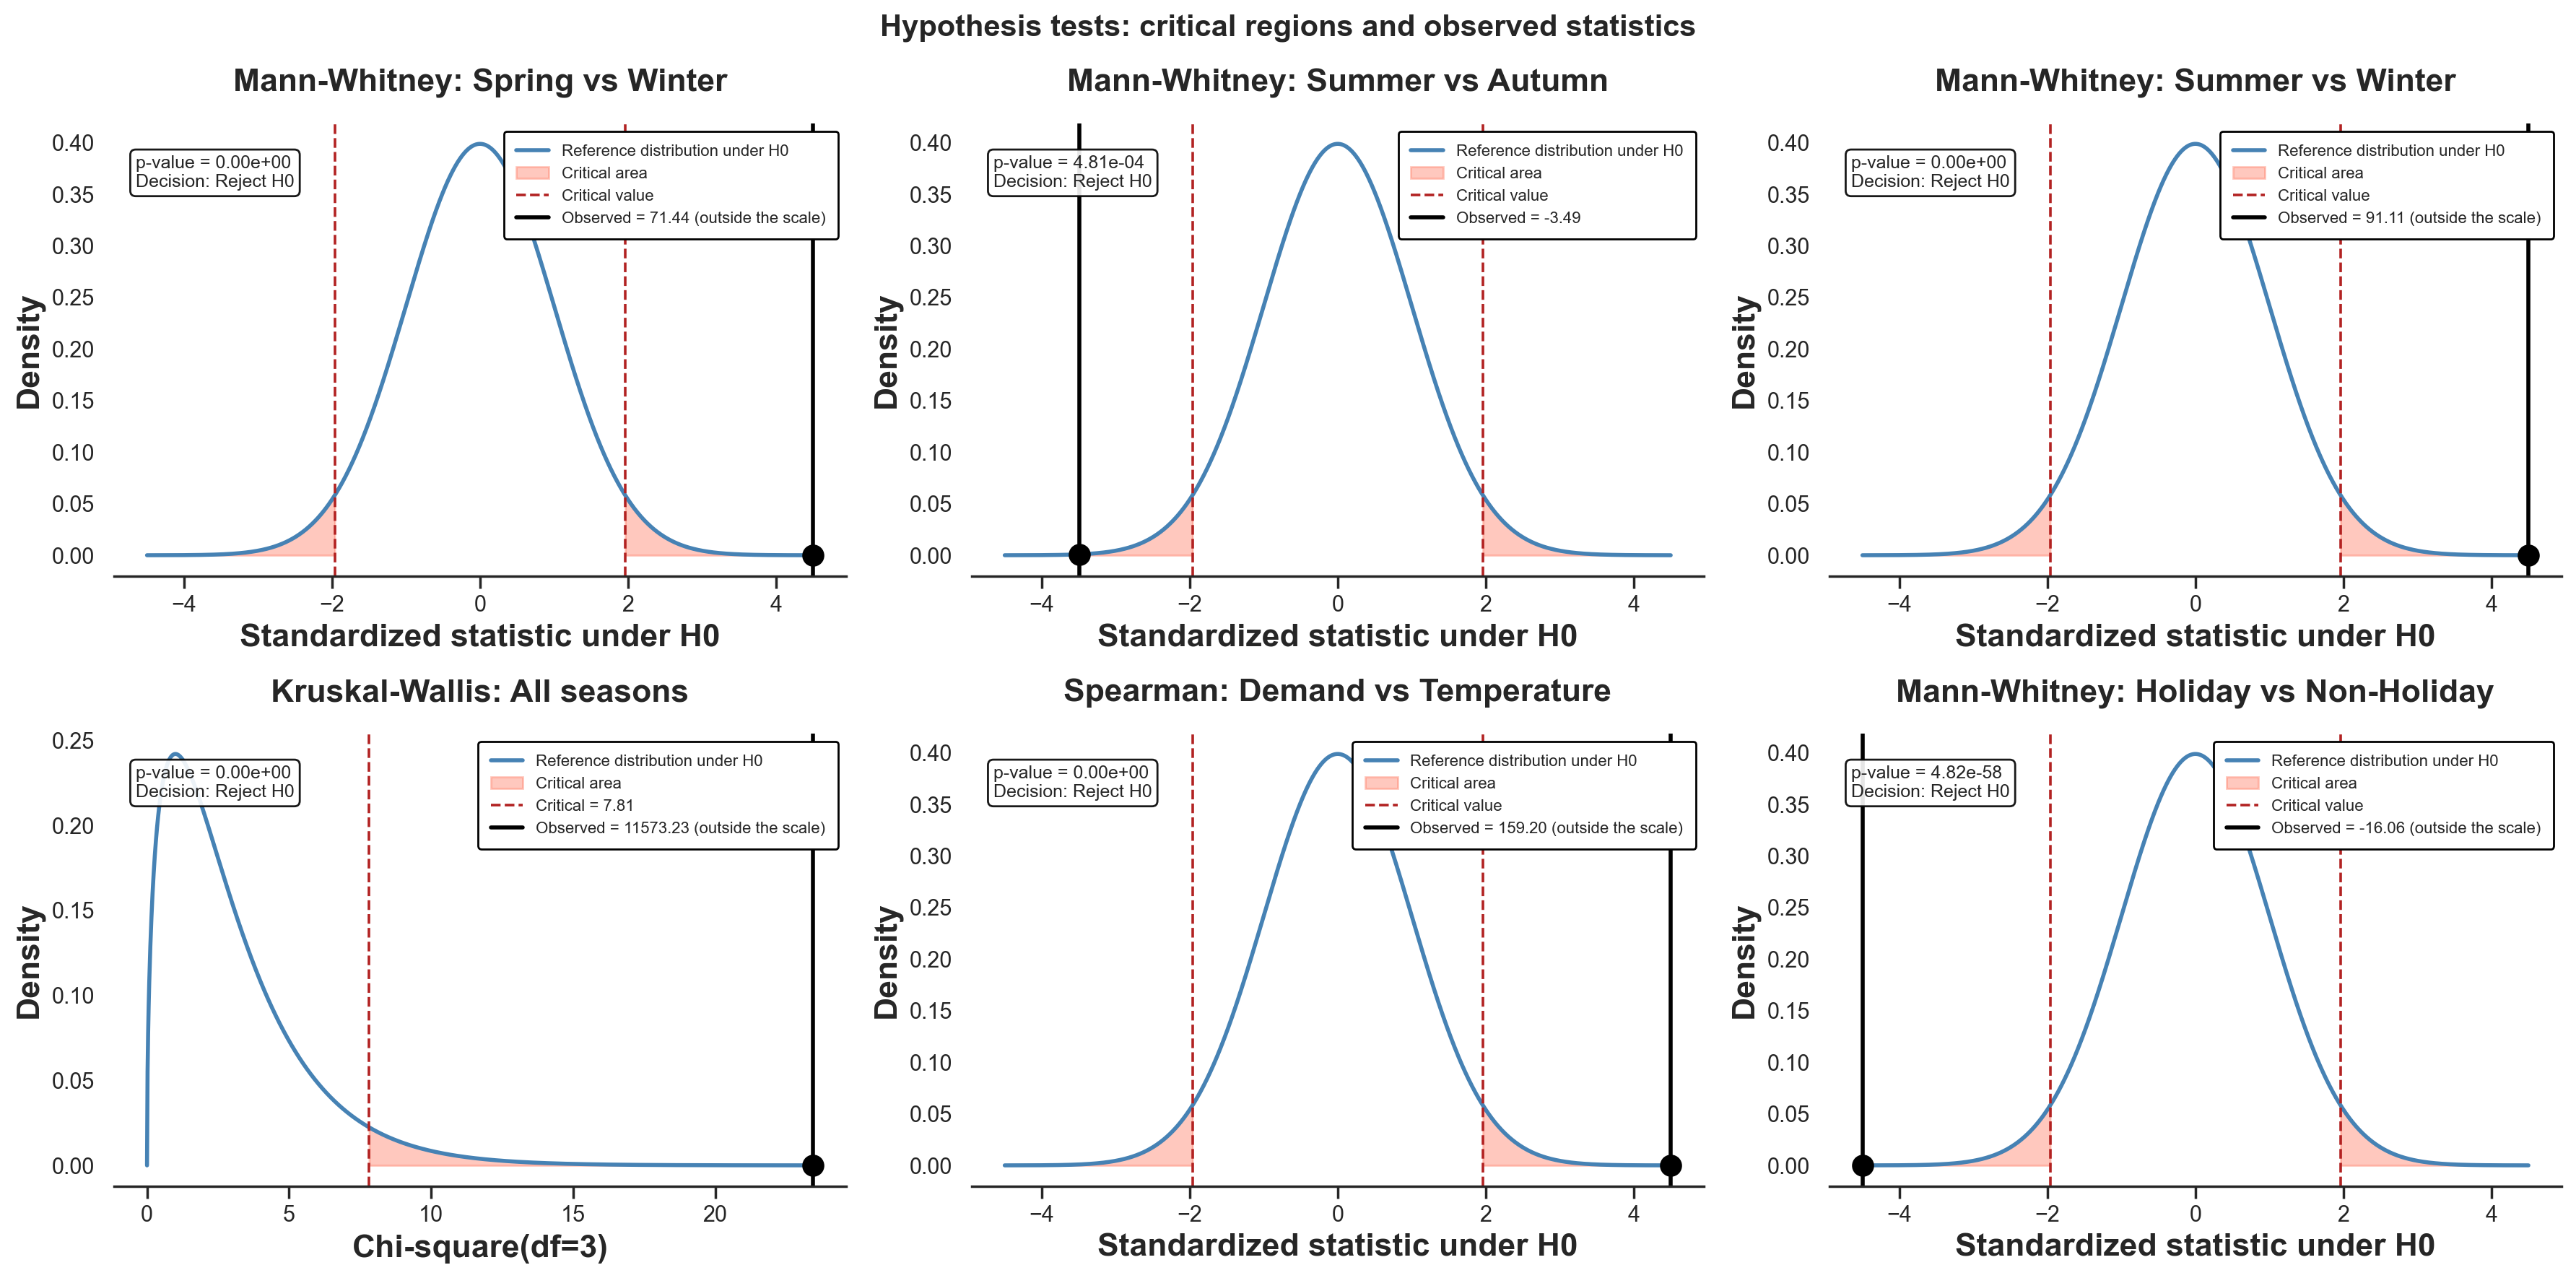

In [14]:
seasonal_results = st.seasonal_hypothesis_tests(mv_df, alpha=0.05)
display(st.localize_report(seasonal_results, lang=lang))
st.plot_seasonal_hypothesis_tests(seasonal_results, lang=lang)
plt.show()


In [15]:
# Relatório compacto: magnitude prática e inferência ajustada por multiplicidade
seasonal_report = st.localize_report(st.seasonal_report_table(seasonal_results), lang=lang)
seasonal_labels = lang({
    'effect_size': 'Tamanho do efeito',
    'p_value': 'valor-p',
    'holm_p_value': 'valor-p de Holm',
})
print(seasonal_report.to_string(index=False, formatters={
    seasonal_labels['effect_size']: '{:.3f}'.format,
    seasonal_labels['p_value']: '{:.3e}'.format,
    seasonal_labels['holm_p_value']: '{:.3e}'.format,
}))


                                Test             N                 Group medians  Effect measure Effect size   p-value Holm p-value Holm decision
      Mann-Whitney: Spring vs Winter 19178 / 19540                 0.837 / 0.369 rank-biserial r       0.419 0.000e+00    0.000e+00     Reject H₀
      Mann-Whitney: Summer vs Autumn 17594 / 18992                 1.023 / 1.070 rank-biserial r      -0.021 4.814e-04    4.814e-04     Reject H₀
      Mann-Whitney: Summer vs Winter 17594 / 19540                 1.023 / 0.369 rank-biserial r       0.547 0.000e+00    0.000e+00     Reject H₀
         Kruskal-Wallis: All seasons         75304 0.837 / 1.023 / 1.070 / 0.369 epsilon-squared       0.154 0.000e+00    0.000e+00     Reject H₀
     Spearman: Demand vs Temperature         75304                           NaN    Spearman rho       0.502 0.000e+00    0.000e+00     Reject H₀
Mann-Whitney: Holiday vs Non-Holiday  3745 / 71559                 0.449 / 0.730 rank-biserial r      -0.155 4.822e-58    9.

> **Insights from Seasonal Hypothesis Tests**
>
> The six hypotheses were rejected both by the nominal criterion and after Holm correction. The values presented as `0.000e+00` do not represent mathematically zero probability; the numerical limit of the computational representation was exceeded by very distant statistics from the reference distribution. With the large hourly sample, the rejection of $H_0$ should not be confused with practical relevance.
>
> The contrasts involving winter produced the most expressive seasonal differences. Between spring and winter, medians of `0.837` and `0.369` were observed, with $r_{rb}=0.419$. Between summer and winter, the medians were `1.023` and `0.369`, with $r_{rb}=0.547$. By the global test, $H=11.573,23$ and $\epsilon^2=0.154$ were obtained, so that a relevant seasonal heterogeneity was sustained for the demand index. The global rejection, isolated, does not allow stating that all seasons differ from each other.
>
> The summer–autumn contrast demonstrated the effect of the sample size on significance: although `p=0.000481` remained significant after Holm, close medians were obtained (`1.023` and `1.070`) and the effect size was practically zero ($r_{rb}=-0.021$). A statistical difference was detected, but it was not sustained that an operationally important separation between these two distributions exists.
>
> A moderate positive monotonic association was observed between temperature and relative demand ($\rho_s=0.502$). Thus, higher indices tend to accompany higher temperatures, but the association remained distant from a perfect ordering and a substantial portion of the relative variation was not described by the temperature alone. Since temperature and season share temporal structure, an independent causal effect of temperature was not identified.
>
> On holidays, a median of `0.449` was observed, against `0.730` on other days, with $r_{rb}=-0.155$. A relative reduction was indicated, but the effect was small and the groups were strongly imbalanced (`3.745` against `71.559` observations). Calendar differences, climate, time, and operational regime were not controlled; therefore, a causal effect of holiday was not demonstrated.
>
> Since the temporal dependence of hourly observations was not incorporated into the tests, the inferential evidence must be considered exploratory. The effect sizes and stability in temporal validation will receive priority over p-values in the modeling process. `Seasons`, `Temperature(C)`, and `Holiday` will be maintained as candidate features, and their final utility will be delegated to the selectors and estimators evaluated outside the sample.


## 6. Feature Selection: Chi², ANOVA, and F-regression

Three complementary univariate filters are applied. Chi² is used to examine the association between each categorical feature and demand bands; ANOVA is used to examine the separation of each numerical feature's means across those bands; and F-regression is used to directly examine the linear association between each encoded column and the continuous index. Because each predictor is evaluated in isolation, interactions, conditional redundancies, and incremental gain in the presence of the remaining features are not measured.

For Chi² and ANOVA, the detrended index is discretized with `pd.qcut` into five approximately equal-frequency quantiles, from `Q1` through `Q5`. These bands are produced only within this exploratory analysis and are not added to `mv_df`. If they were calculated before the training-validation split in a predictive pipeline, information from the full target distribution would be incorporated into preprocessing, introducing leakage. F-regression uses the continuous index without this discretization.

The nominal level is set at `α=0.05`, and the Holm correction is applied separately to the family of features examined by each method. The adjusted decision is used to control multiplicity, but the large number of hourly observations and temporal dependence make p-values insufficient for selection. Cramér's V, `η²`, and univariate `R²` are therefore prioritized in the interpretation.

### Chi² Test of Independence for Categorical Features

For each categorical variable, a contingency table is constructed between its categories and the five target quantiles. Under $H_0$, independence between the two classifications is assumed; under $H_1$, some association is admitted. The [Pearson (1900)](https://doi.org/10.1080/14786440009463897) statistic is calculated directly from the observed and expected frequencies. As a result, nominal categories are not assigned artificial integer codes, and the degrees of freedom are calculated as `(n_rows − 1) × (n_columns − 1)` for each table.

Because the Chi² statistic increases with sample size and table dimensions, the ranking is not produced from its raw value. Standardized strength is summarized by Cramér's V, which is bounded to the interval `[0, 1]`. The minimum expected frequency and the percentage of cells with an expected frequency below 5 are also presented, allowing the adequacy of the asymptotic approximation to be verified rather than presumed.


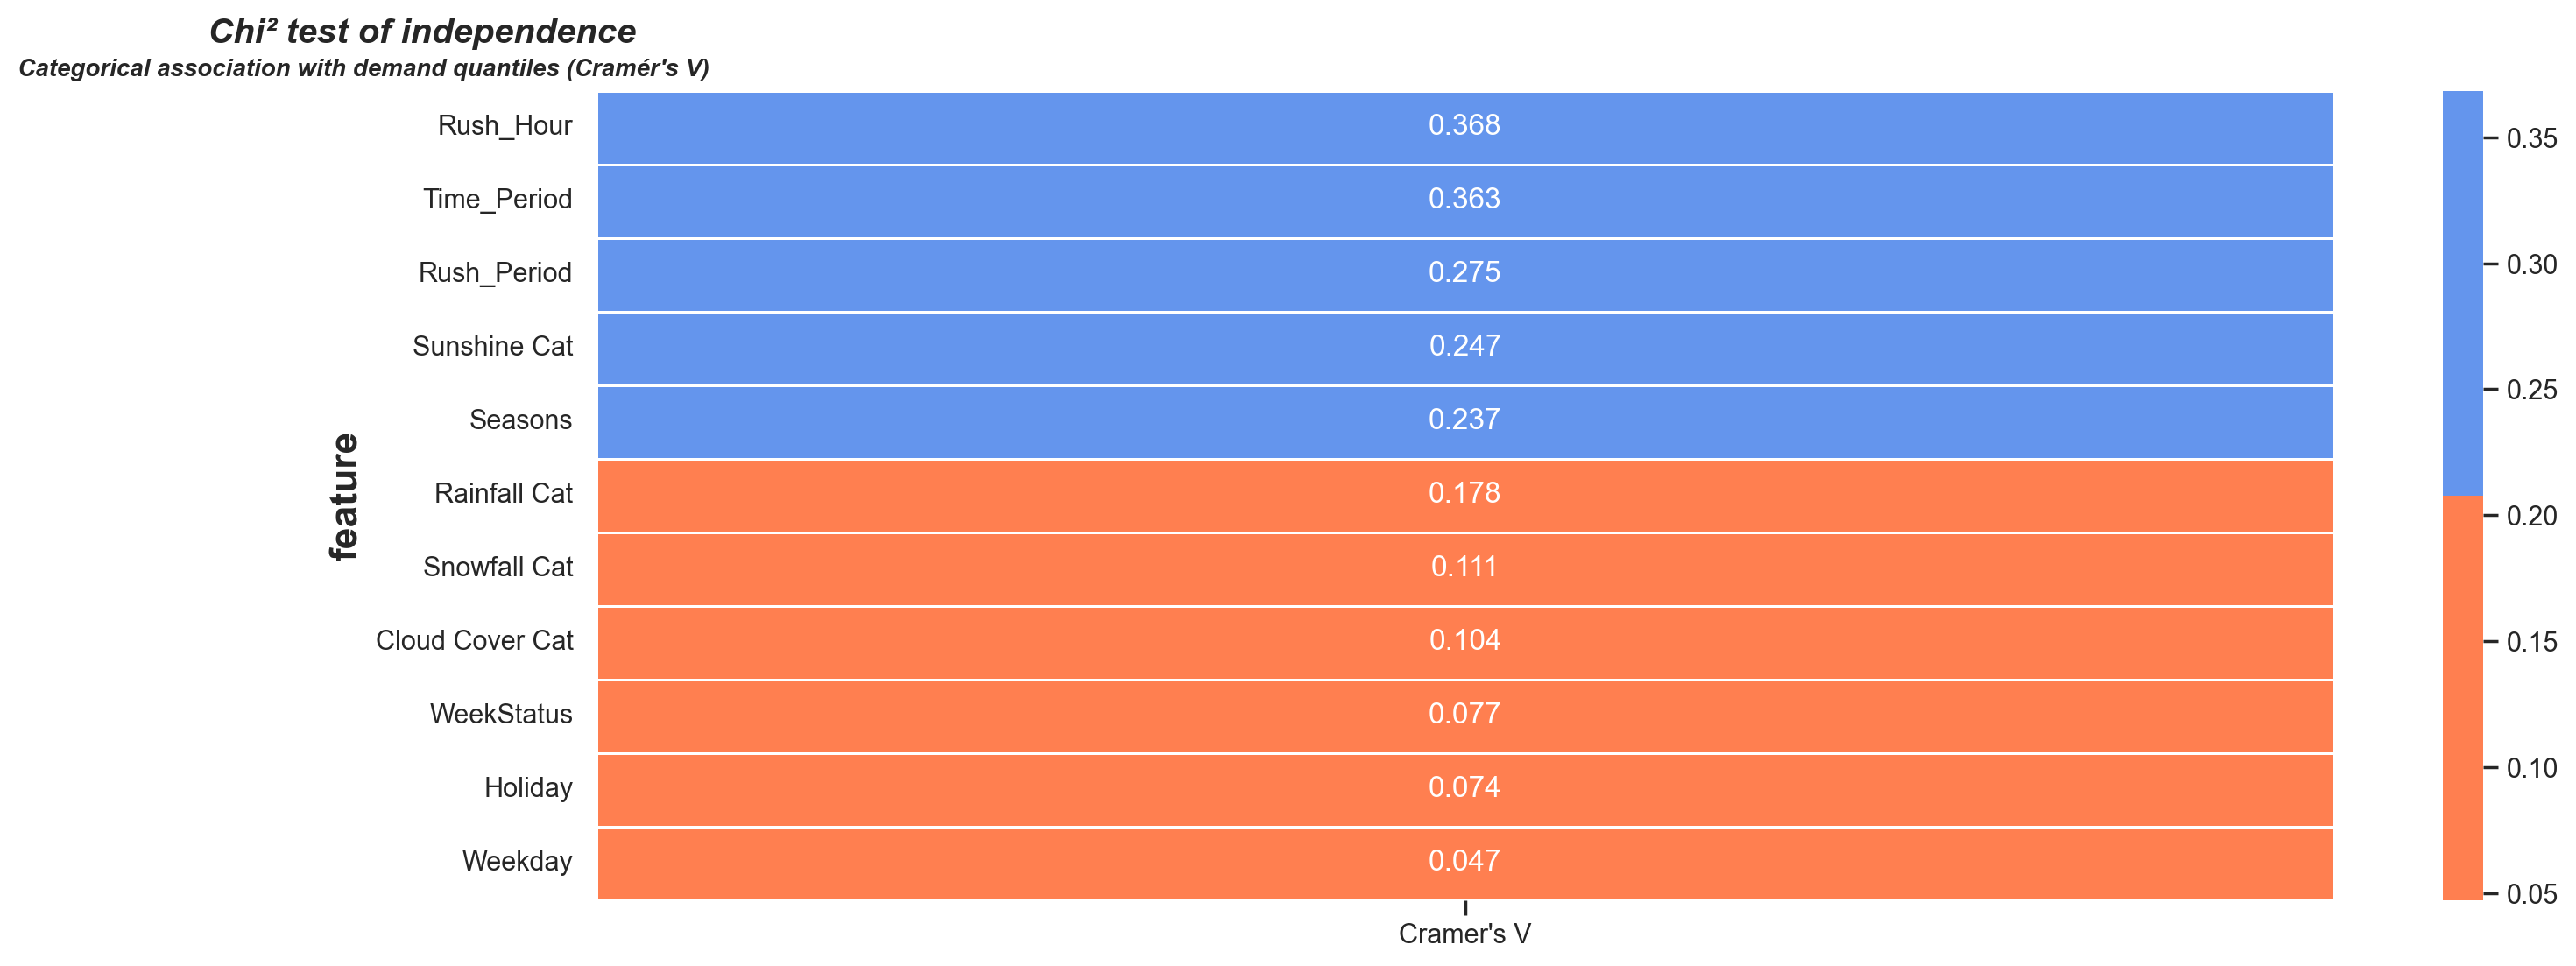

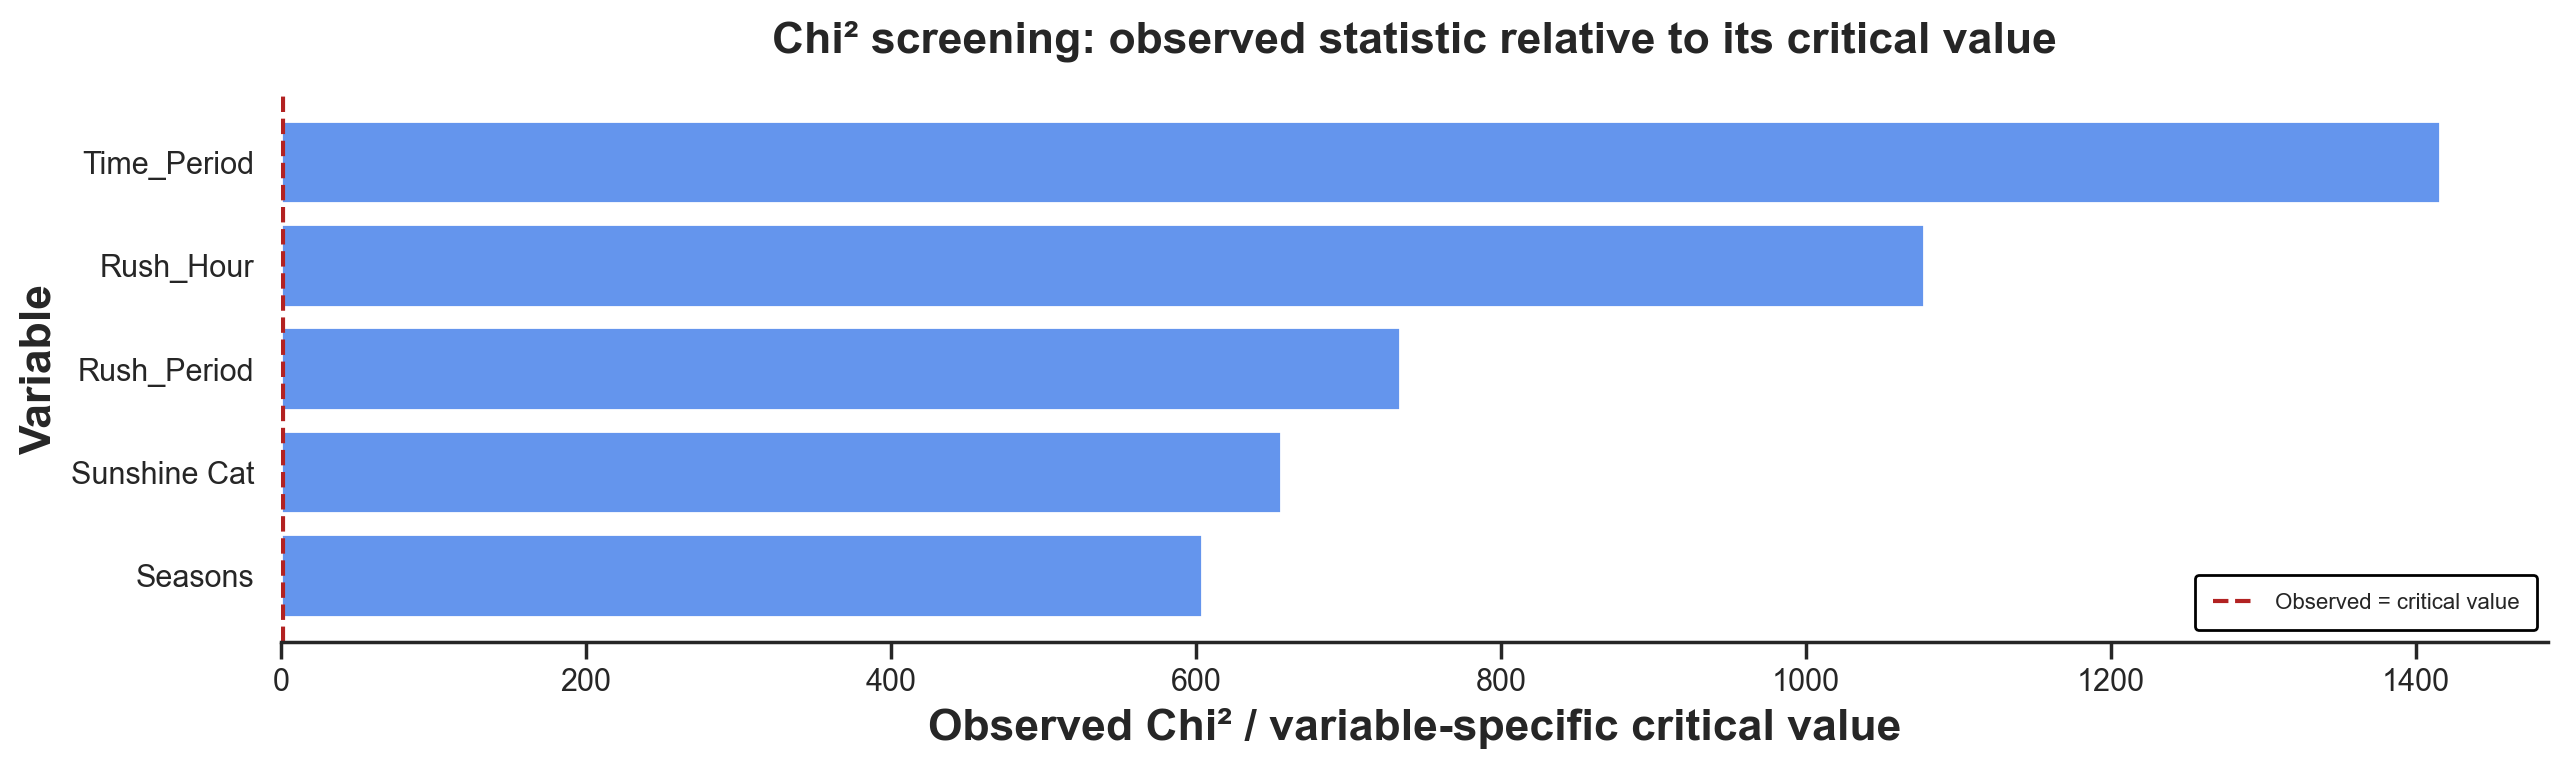

,Cramér's V,Chi-square statistic,df,Minimum expected count,Expected cells < 5 (%),Holm p-value,Holm decision
feature,,,,,,,
Rush_Hour,0.368500,10225.684780,4,2975.441942,0.0,0.000000e+00,Reject H₀
Time_Period,0.363051,29776.534326,12,3743.001169,0.0,0.000000e+00,Reject H₀
Rush_Period,0.274896,11381.150319,8,1275.932221,0.0,0.000000e+00,Reject H₀
Sunshine Cat,0.247019,13784.770740,12,779.158610,0.0,0.000000e+00,Reject H₀
Seasons,0.237161,12706.535647,12,3518.613088,0.0,0.000000e+00,Reject H₀
Rainfall Cat,0.177795,7141.336576,12,66.196484,0.0,0.000000e+00,Reject H₀
Snowfall Cat,0.110671,2766.978593,12,64.396579,0.0,0.000000e+00,Reject H₀
Cloud Cover Cat,0.104440,2464.202064,12,1093.541910,0.0,0.000000e+00,Reject H₀
WeekStatus,0.076896,445.270554,4,4304.171359,0.0,9.147409e-95,Reject H₀


In [16]:
chi_scores, _, _ = st.chi_square_feature_selection(
    mv_df, target_col=TARGET, alpha=0.05, lang=lang)
plt.show()
st.plot_chi_square_critical_region(chi_scores, lang=lang)
plt.show()
chi_report = st.chi_square_report(chi_scores)
display(st.localize_report(chi_report, lang=lang))


### ANOVA for Feature Selection of Numerical Features

The analysis of variance developed in the tradition of [Fisher (1925)](https://openlibrary.org/works/OL1153861W/Statistical_methods_for_research_workers) is applied in a specific orientation: each numerical feature is treated as an analyzed variable, and the five quantiles of the demand index are treated as groups. Under $H_0$, the means of the feature are equal between `Q1` and `Q5`; under $H_1$, at least one mean differs. Therefore, separation between demand levels is examined, but a linear relationship with the target is not necessarily established.

The ratio between intergroup and intragroup variability is summarized by the F statistic. Since the degrees of freedom are equal for all features in this block, the ranking by F coincides with the ranking by $\eta^2$; nonetheless, $\eta^2$ is presented as possessing an interpretable scale as a fraction of the feature's variability associated with the target's bins. The p-values are adjusted by Holm.

Conditional normality, homogeneity of variances, and independence of observations are the classical F reference's assumptions and are not demonstrated by the hourly data. Furthermore, `Hour`, `Month`, and `DayNumberOnWeek` are cyclic representations stored as numbers, so that distances at the scale's extremes can be interpreted inadequately. The results are used as relative triage, not as causal inference nor as automatic justification for dismissal.


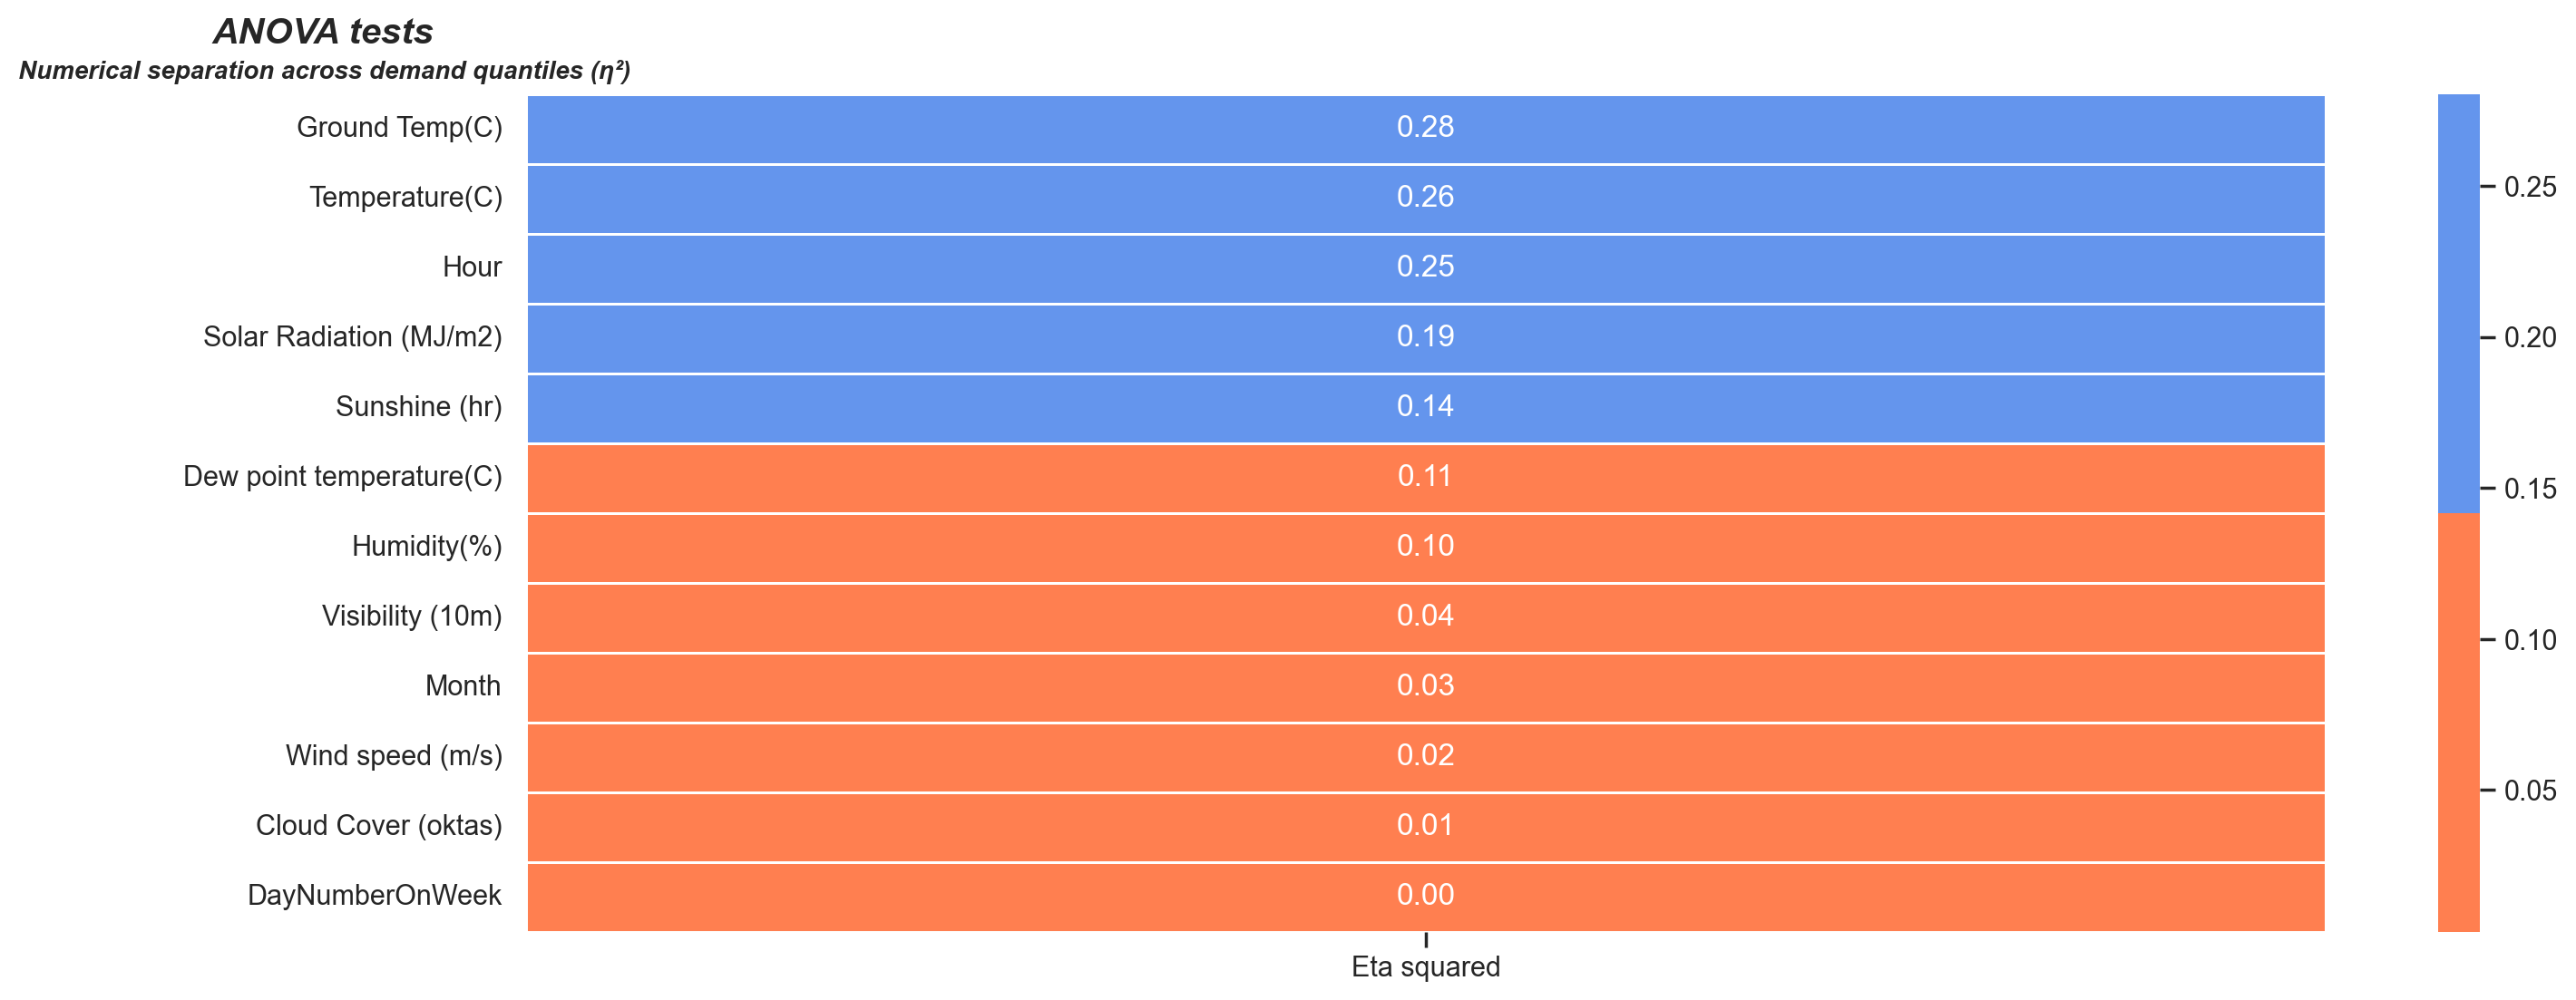

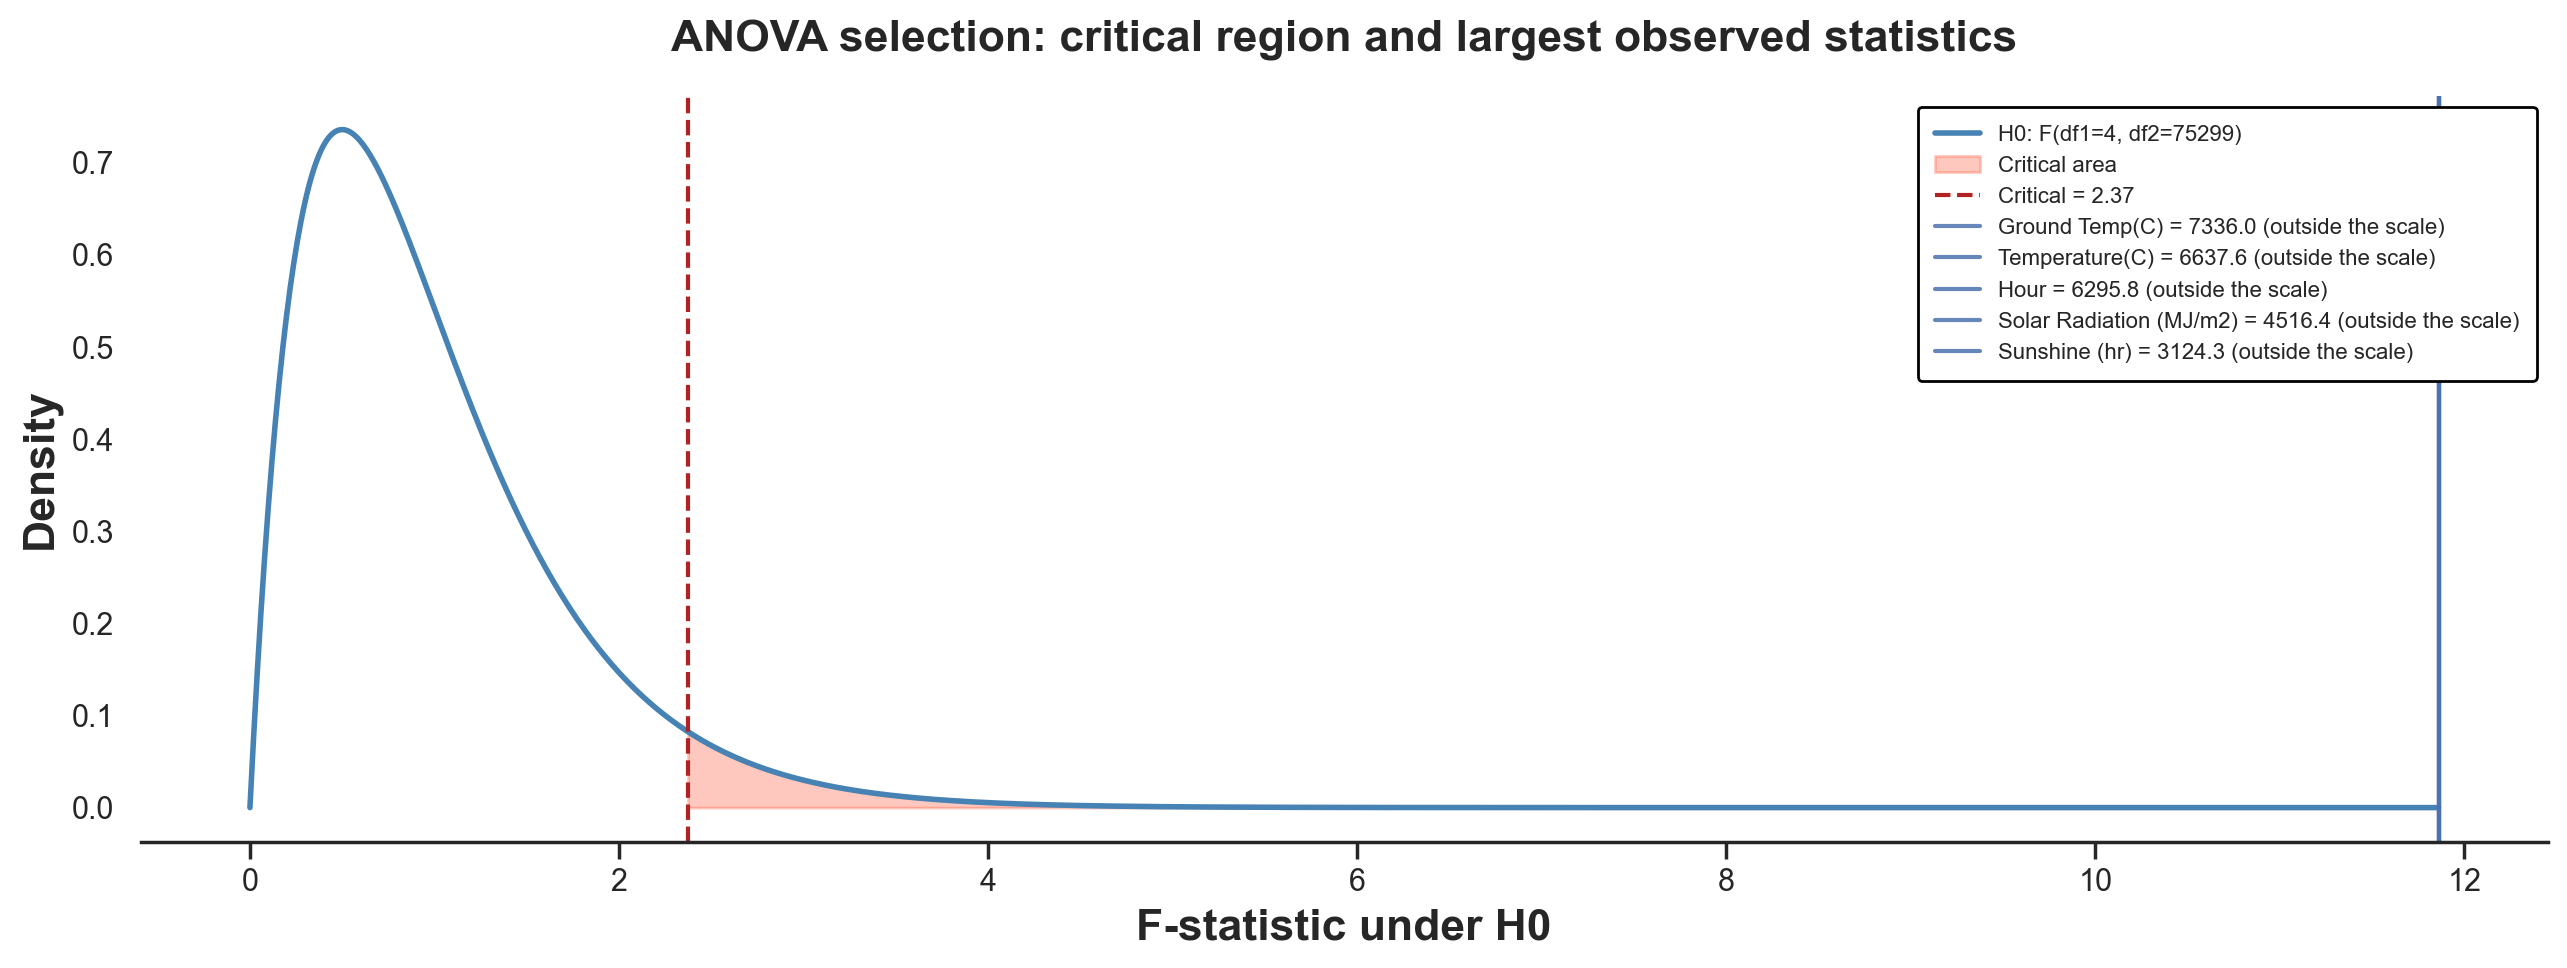

,Eta-squared (η²),ANOVA statistic,df1,df2,Holm p-value,Holm decision
Ground Temp(C),0.280419,7335.952297,4,75299,0.000000e+00,Reject H₀
Temperature(C),0.260683,6637.594907,4,75299,0.000000e+00,Reject H₀
Hour,0.250624,6295.812062,4,75299,0.000000e+00,Reject H₀
Solar Radiation (MJ/m2),0.193497,4516.449503,4,75299,0.000000e+00,Reject H₀
Sunshine (hr),0.142342,3124.270962,4,75299,0.000000e+00,Reject H₀
Dew point temperature(C),0.105675,2224.356827,4,75299,0.000000e+00,Reject H₀
Humidity(%),0.098514,2057.154796,4,75299,0.000000e+00,Reject H₀
Visibility (10m),0.039329,770.661866,4,75299,0.000000e+00,Reject H₀
Month,0.025510,492.785453,4,75299,0.000000e+00,Reject H₀
Wind speed (m/s),0.018855,361.763064,4,75299,1.220853e-308,Reject H₀


In [17]:
num_features = [c for c in mv_df.select_dtypes(include=[np.number]).columns
                if c not in (TARGET, 'is_anomalous_2020')]
target_bins = pd.qcut(mv_df[TARGET], q=5, labels=[f'Q{i}' for i in range(1, 6)])

anova_scores, _, _ = st.anova_feature_selection(
    mv_df, num_features, target_bins, alpha=0.05, lang=lang)
plt.show()
st.plot_anova_critical_region(anova_scores, lang=lang)
plt.show()
anova_report = st.anova_report(anova_scores)
display(st.localize_report(anova_report, lang=lang))


### F-regression on the Continuous Index

In F-regression, target discretization is abandoned and a simple linear regression is fitted separately between each column and the continuous index. According to the [scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.f_regression.html), the Pearson correlation between each regressor and the target is converted into an F-statistic and its p-value. Categorical features are first represented by indicator variables with `drop_first=True`; each retained dummy is therefore examined separately, while the omitted category does not receive its own score.

Univariate `R²` is presented as a measure of each column's linear strength. The former label `Contribution (%)` is replaced by `Relative F share (%)` because each F-statistic's share of the sum of scores is only a visualization normalization: the F-values are calculated in separate models, are not additive components, and do not represent independent percentages of explained demand.

Nonlinear associations, interactions, and incremental utility are not captured. Redundant variables may simultaneously receive high scores, whereas a feature that is useful only in combination may receive a low score. The Holm correction is applied to the p-values, but the practical ranking is produced by univariate `R²` and must be compared with the multivariate selectors and the pipeline's temporal validation.


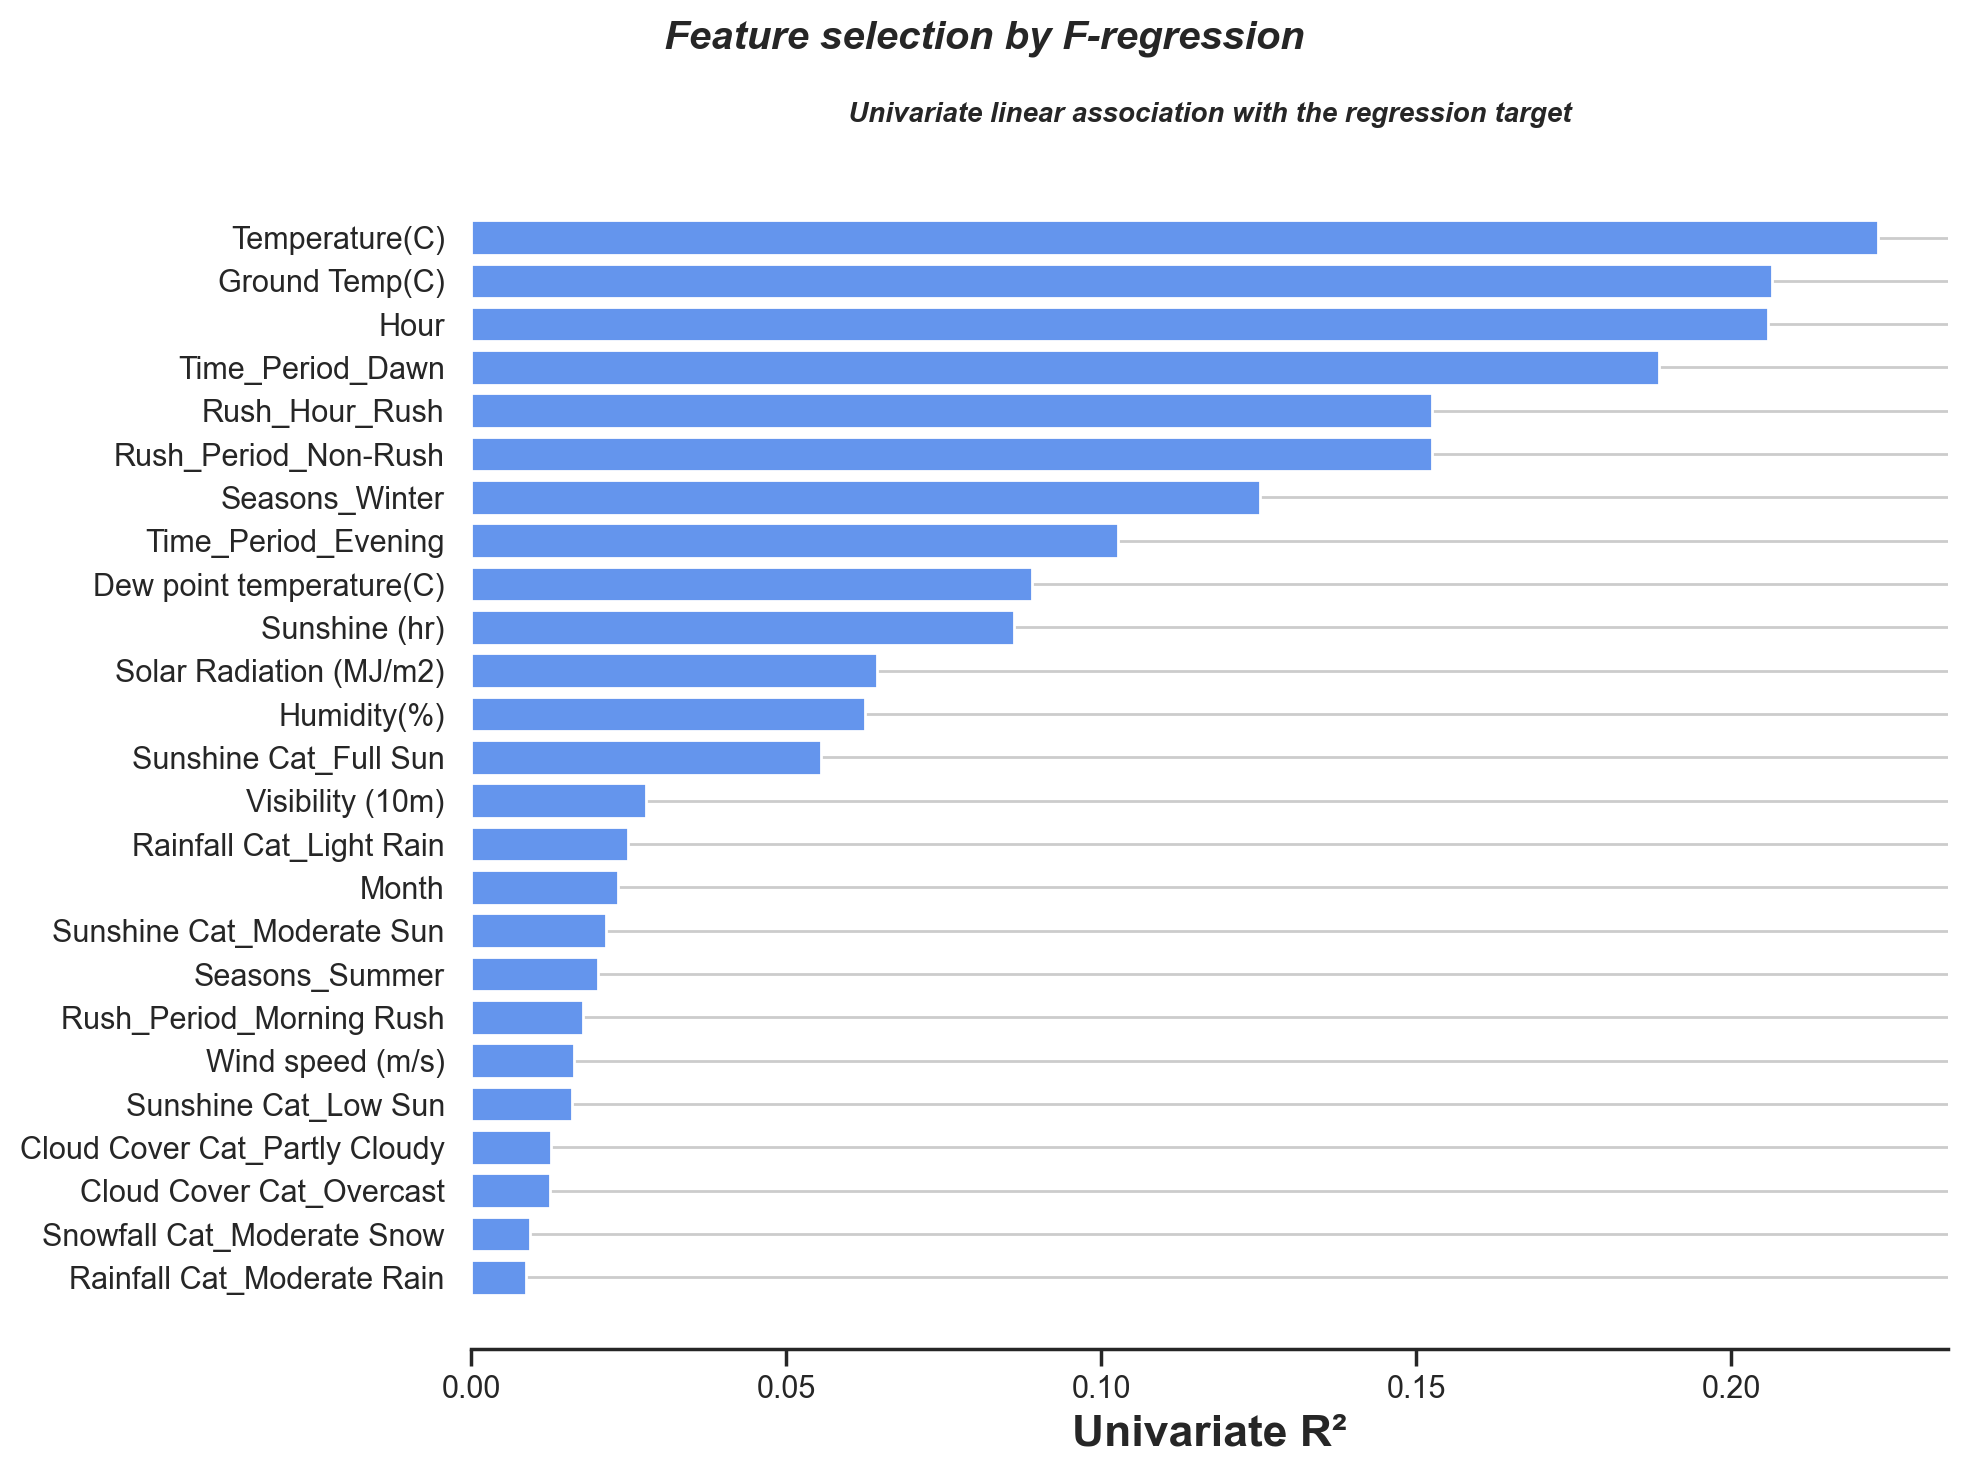

,Univariate R²,F-statistic,Relative F share (%),Holm p-value,Holm decision
Temperature(C),0.223323,21652.089603,12.530342,0.0,Reject H₀
Ground Temp(C),0.206420,19586.948817,11.335219,0.0,Reject H₀
Hour,0.205860,19520.071740,11.296516,0.0,Reject H₀
Time_Period_Dawn,0.188519,17493.717104,10.123839,0.0,Reject H₀
Rush_Hour_Rush,0.152529,13552.941631,7.843261,0.0,Reject H₀
Rush_Period_Non-Rush,0.152529,13552.941631,7.843261,0.0,Reject H₀
Seasons_Winter,0.125186,10775.758839,6.236070,0.0,Reject H₀
Time_Period_Evening,0.102673,8616.136487,4.986269,0.0,Reject H₀
Dew point temperature(C),0.089086,7364.440998,4.261897,0.0,Reject H₀
Sunshine (hr),0.086121,7096.237173,4.106684,0.0,Reject H₀


In [18]:
f_scores, _, _ = st.f_regression_feature_selection(
    mv_df, target_col=TARGET, alpha=0.05, top_n=25, lang=lang)
plt.show()
f_report = st.f_regression_report(f_scores)
display(st.localize_report(f_report.head(15), lang=lang))


### Consolidated Report for Interpretation

The previous calculation blocks have been updated to the new metrics and will regenerate their graphs when the section is executed. The following saved text report gathers the corrected results that underlie the insight: Cramér's V for Chi², `η²` for ANOVA, and univariate `R²` for F-regression.


In [19]:
# Relatório compacto de tamanho de efeito (tabelas preparadas em src.stats_tests)
print(st.univariate_selection_summary(chi_report, anova_report, f_report, lang=lang))


CHI-SQUARE — categorical features
                 Cramér's V  df  Minimum expected count   Holm p-value Holm decision
feature                                                                             
Rush_Hour          0.368500   4             2975.441942   0.000000e+00     Reject H₀
Time_Period        0.363051  12             3743.001169   0.000000e+00     Reject H₀
Rush_Period        0.274896   8             1275.932221   0.000000e+00     Reject H₀
Sunshine Cat       0.247019  12              779.158610   0.000000e+00     Reject H₀
Seasons            0.237161  12             3518.613088   0.000000e+00     Reject H₀
Rainfall Cat       0.177795  12               66.196484   0.000000e+00     Reject H₀
Snowfall Cat       0.110671  12               64.396579   0.000000e+00     Reject H₀
Cloud Cover Cat    0.104440  12             1093.541910   0.000000e+00     Reject H₀
WeekStatus         0.076896   4             4304.171359   9.147409e-95     Reject H₀
Holiday            0.074411   4

> **Insights from Univariate Feature Selection**
>
> After the Chi² was calculated directly on contingency tables, all ten categorical features remained associated with the demand quantiles according to the Holm criterion. The highest intensities were obtained for `Time_Period` (`V=0.363`), `Rush_Hour` (`V=0.356`), `Sunshine Cat` (`V=0.247`), and `Seasons` (`V=0.237`). For `Weekday` (`V=0.047`), `Holiday` (`V=0.074`), and `WeekStatus` (`V=0.077`), weak associations were observed despite reduced p-values.
>
> The Chi² approximation was not compromised by small expected frequencies: no cell presented an expectation less than 5, and the smallest value was `64.4`. The methodological change altered the previous ranking because the magnitude of the codes assigned by the `LabelEncoder` no longer participated in the calculation. The interpretation now depends solely on the joint frequencies of the categories and the quantiles.
>
> In ANOVA, the largest separation between demand quantiles was obtained for `Ground Temp(C)` (`η²=0.280`), `Temperature(C)` (`η²=0.261`), `Hour` (`η²=0.251`), `Solar Radiation (MJ/m2)` (`η²=0.193`), and `Sunshine (hr)` (`η²=0.142`). Although all features remained significant after Holm, very small effects were obtained for `DayNumberOnWeek` (`η²=0.003`) and `Cloud Cover (oktas)` (`η²=0.008`). This reinforced the need to separate significance from discriminative capacity.
>
> By F-regression, the largest isolated linear adjustments were produced by `Temperature(C)` (`R²=0.223`), `Ground Temp(C)` (`R²=0.206`), `Hour` (`R²=0.206`), `Time_Period_Dawn` (`R²=0.189`), `Rush_Hour_Rush` (`R²=0.141`), and `Seasons_Winter` (`R²=0.125`). Only `Weekday_Monday` did not remain significant after Holm, but its `R²=0.000021` also confirmed the absence of isolated linear relevance. No global irrelevance of `Weekday` was demonstrated: by Chi², the complete variable remained associated with the quantiles, while F-regression evaluated only the specific indicator of Monday.
>
> The agreement between ANOVA and F-regression placed temperature, soil temperature, and hour among the strongest univariate signals. This convergence should not be interpreted as independent contribution: high collinearity was demonstrated between thermal variables, and derived representations of hour and season share information. The `R²` and F-scores cannot be summed to estimate the demand explained by the set.
>
> The three methods measure different objects, and therefore their rankings do not need to coincide. Chi² depends on the discretization of both sides; ANOVA measures the separation of the feature mean between demand quantiles; and F-regression measures linear association with the continuous index. None of them evaluates interactions, temporal stability, or incremental gain conditioned on the remaining features.
>
> As a project decision, no manual exclusion will be executed based on these rankings. The `Q1`–`Q5` bands will not be used as the target or feature for modeling, and the results of this section will remain as exploratory diagnosis. The effective selection will be delegated to `SelectKBest`, `RFE`, `SelectFromModel`, `SequentialFeatureSelector`, or `NoSelector`, according to the estimator and temporal validation; in the optimization pipeline, the `SelectKBest` uses `mutual_info_regression`, and not the tests presented in this section.


## 7. Shapiro-Wilk and Anderson-Darling Tests for Normality

The marginal distributions of the deseasonalized demand index, temperature, and humidity are evaluated in this section. In the Shapiro–Wilk test, introduced by [Shapiro and Wilk (1965)](https://doi.org/10.1093/biomet/52.3-4.591), the null hypothesis that the sample was drawn from a Normal population is tested. As warned in the [SciPy documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html), the p-value may be inaccurate for `N > 5,000`. A reproducible sample of up to 5,000 observations is selected with `random_state=42`; the original sample size and the effectively tested sample size are maintained in the report.

As a complementary check, the Anderson–Darling test, proposed by [Anderson and Darling (1952)](https://doi.org/10.1214/aoms/1177729437), is applied to all available observations. The observed statistic is compared to the 5% critical value provided for the Normal distribution, according to the [SciPy implementation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.anderson.html). A greater emphasis is placed on tails by this test, but its statistic does not constitute a measure of effect size and should not be ordered between variables as if it directly quantified the importance of non-normality.

Due to the sample size, small deviations from Normal can be detected with high power. Therefore, decisions are accompanied by the median, interquartile range, skewness, and excess kurtosis. The marginal normality of the columns is not a general requirement for ANOVA or regression: when this assumption is necessary, it falls on the errors or the conditional distributions of the model, and not automatically on each isolated variable. Thus, a rejection in this section does not determine, by itself, transformation, feature exclusion, or substitution of all parametric procedures.

Since the observations are hourly and ordered in time, independence and identical distribution cannot be assumed. The p-values and critical values are therefore used as marginal exploratory diagnostics; the inferential adequacy of a model should be verified later on residuals and validations that preserve the temporal order.

### Kruskal–Wallis for Rain and Snow Categories

- *`Is demand equal when it's raining or snowing?`*

For the rain and snow categories, the global Kruskal–Wallis test is applied, testing the null hypothesis of equal distributions between groups. The sizes and medians of each category are presented, along with the statistic `H` and the effect size `ε²`. Since two meteorological families are tested, the p-values are corrected by the Holm procedure. A global rejection indicates that at least one distribution differs from the others, but does not identify which pairs differ; post-hoc comparisons would be necessary for this purpose. Seasonal, hourly, and compositional differences between categories also prevent the observed association from being interpreted as a causal effect of precipitation.


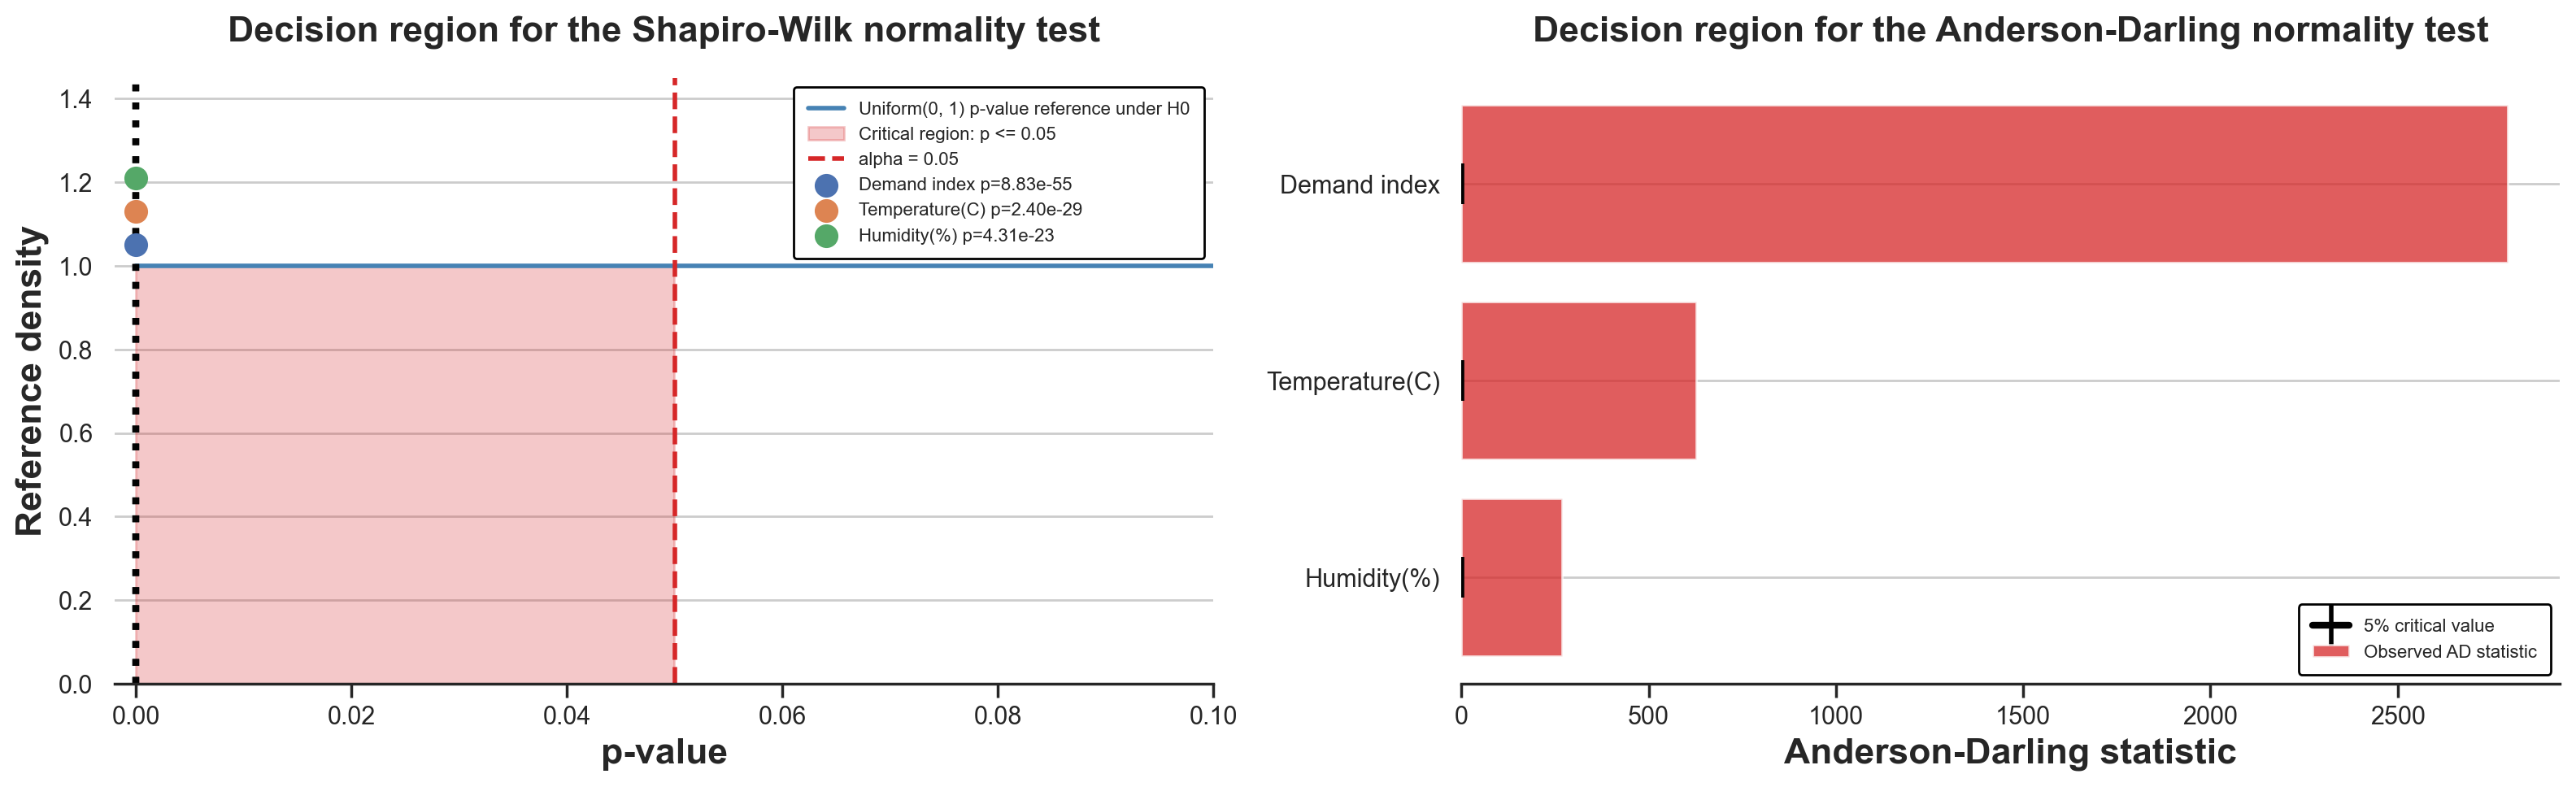

,Group,N,Median,IQR,Skewness,Excess kurtosis,N used (Shapiro),W-statistic (Shapiro),p-value (Shapiro),Decision (Shapiro),Anderson-Darling statistic,AD critical value (5%),AD significance level used (%),Decision (Anderson-Darling)
0,Demand index,75304,0.71696,1.09044,1.505309,2.765754,5000,0.862028,8.829419e-55,Reject H₀,2793.909494,0.787,5.0,Reject H₀
1,Temperature(C),75304,14.00000,18.60000,-0.199450,-0.934866,5000,0.973788,2.399753e-29,Reject H₀,627.724558,0.787,5.0,Reject H₀
2,Humidity(%),75304,62.00000,30.00000,-0.102800,-0.829450,5000,0.984382,4.314963e-23,Reject H₀,269.258679,0.787,5.0,Reject H₀


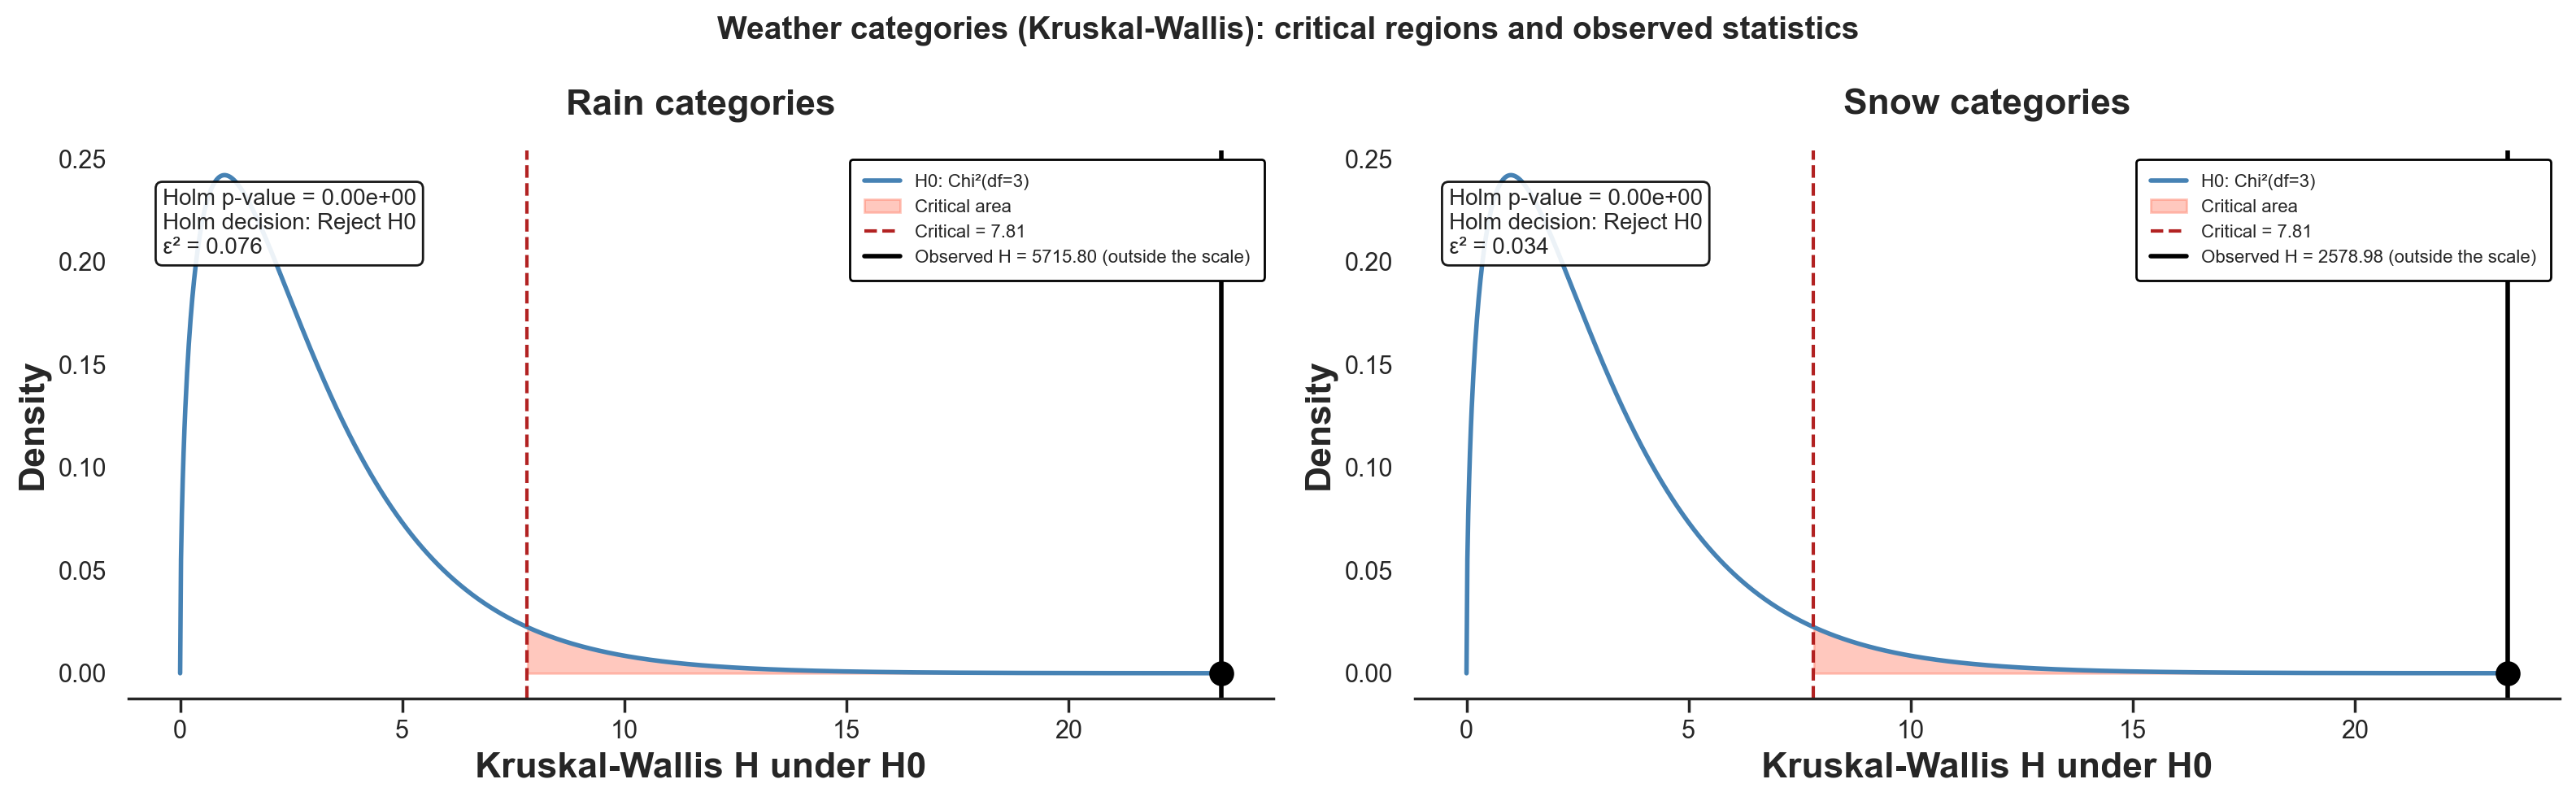

,Test,N,Groups,Group summary,df,Observed H,Epsilon-squared,Critical value,p-value,Decision,Holm p-value,Holm decision
0,Rain categories,75304,4,"No Rain: n=71,157, median=0.766 | Light Rain: ...",3,5715.804639,0.075867,7.814728,0.0,Reject H₀,0.0,Reject H₀
1,Snow categories,75304,4,"No Snow: n=72,787, median=0.748 | Light Snow: ...",3,2578.981206,0.034210,7.814728,0.0,Reject H₀,0.0,Reject H₀


In [20]:
idx_label = lang({'idx': 'Índice de demanda'})['idx']
norm_df, _, _ = st.normality_tests(
    {idx_label: mv_df[TARGET], 'Temperature(C)': mv_df['Temperature(C)'],
     'Humidity(%)': mv_df['Humidity(%)']}, alpha=0.05, lang=lang)
plt.show()
display(st.localize_report(norm_df, lang=lang))

kruskal_df, _, _ = st.kruskal_weather_test(mv_df, alpha=0.05, lang=lang)
plt.show()
display(st.localize_report(kruskal_df, lang=lang))


> **Insights from normality tests and Kruskal–Wallis:**
>
> The normality hypothesis was rejected for the three variables by both the Shapiro–Wilk and Anderson–Darling tests. In the Shapiro–Wilk, values of `W = 0.862` were obtained for the demand index, `W = 0.974` for temperature, and `W = 0.984` for humidity, always over the reproducible sample of 5,000 observations. The largest deviation from 1 was observed in the target; for temperature and humidity, values of `W` close to 1 coexisted with very small p-values, as would be expected given the high sample power.
>
> The form of this difference was clarified by the calculated descriptors over the 75,304 observations. Positive skewness (`1.505`) and positive excess kurtosis (`2.766`) were observed in the demand index, whose median was `0.717` and whose interquartile range was `1.090`. Temperature and humidity remained almost symmetric (`−0.199` and `−0.103`), but presented negative excess kurtosis (`−0.935` and `−0.829`), indicating distributions more flattened than a Normal.
>
> In the Anderson–Darling, the statistics of the index, temperature, and humidity (`2.793,909`, `627.725`, and `269.259`) far exceeded the 5% critical value (`0.787`). This evidence confirmed the rejection of the marginal Normal form, but the statistics were not treated as effect sizes nor as a ranking of importance between features.
>
> Global differences between precipitation categories remained significant after Holm correction (`p_Holm < 0.001`). For rain, the median of the index fell from `0.766` without rain to `0.144` with light rain and approximately `0.04` in the moderate and strong categories; it was estimated that `ε² = 0.076`. For snow, the median fell from `0.748` without snow to `0.234`, `0.222`, and `0.127` in the light, moderate, and strong categories, with `ε² = 0.034`. Thus, a greater practical separation was observed for rain, although none of the tests identified the pairs responsible for the rejection alone.
>
> As a temporal dependence, imbalance between groups, and confounding by hour and season were not removed by the global test, and causality was not established. No variable will be transformed or excluded solely by this section. The choice of transformations and estimators will be guided by performance in temporal validation, while any normality assumptions will be reevaluated over the residuals of the model to which they will actually be applied.


## 8. Multivariate Importance (Random Forest: Impurity, Permutation, Ablation, SHAP)

In this section, a `RandomForestRegressor` with 300 trees is used as a diagnostic model to explain the **detrended demand index**, and not the raw count. Non-linear relationships and interactions can be represented by this estimator, but the model is not treated as the final prediction solution. The method follows the formulation of random forests presented by [Breiman (2001)](https://doi.org/10.1023/A:1010933404324).

Four importance perspectives are compared, without their values being summed or subjected to voting. The impurity importance is calculated on the training set by the accumulated quadratic error reduction attributed to each feature cut and is normalized to sum to 1. As continuous variables or those with more possible cuts may be favored and importance may be redistributed between correlated predictors, the ranking is interpreted with the caution discussed by [Strobl et al. (2007)](https://doi.org/10.1186/1471-2105-8-25).

In permutation importance, a holdout column is shuffled in the already adjusted model. As `neg_root_mean_squared_error` is used as the score, the presented value corresponds to the average increase in RMSE caused by permutation; eight shufflings are executed, and the standard deviation only measures the variation between these repetitions. When correlated or deterministic features are represented simultaneously, their information may be shared, and non-existent combinations may be produced by isolated permutation. Therefore, the measure does not equate to a causal effect nor a conditional importance.

In ablation, the model is re-adjusted 24 times, each time without one of the features, and the alteration of the RMSE of the holdout is compared to the baseline. A positive `delta_rmse` indicates deterioration after removal and, therefore, incremental contribution of the variable relative to the others; a negative value indicates a small improvement without it, but does not prove that the feature is detrimental, as redundancy, sampling noise, and the randomness of the adjustment can also produce this difference.

The SHAP values are calculated by `TreeExplainer` over a reproducible sample of up to 500 lines of the holdout, according to the additive framework proposed by [Lundberg and Lee (2017)](https://papers.neurips.cc/paper_files/paper/2017/hash/8a20a8621978632d76c43dfd28b67767-Abstract.html). The mean of `|SHAP|` summarizes the global magnitude of contributions on the scale of the index, while the scatter plot preserves signal and heterogeneity between observations. These contributions explain the adjusted model, not the causal process of demand generation, and may be unstable in redistributing importance between correlated features.

A balanced and reproducible sample of 10,000 records is formed with 1,000 observations per calendar year. The 7,000 lines from 2015–2021 are assigned to training, and the 3,000 lines from 2022–2024 are reserved for the holdout. Thus, a prospective boundary between years is preserved, but the original frequency of records is replaced by equal annual weights, and only one temporal window is evaluated. The metrics do not replace the planned validation by multiple years of meteorological data in the modeling notebook.

The 801 missing values of `Cloud Cover Cat` are explicitly represented by a dedicated category of absence, instead of being silently discarded by the class. The categories are subsequently converted to integer labels, imposing an artificial numerical order on nominal representations; consequently, their importances are specific to this coding and estimator. Additionally, only 46 positive observations of `is_anomalous_2020` remain in the training sample, and none occur in the holdout. A zero permutation importance for this flag is, therefore, inevitable in the holdout and does not allow concluding that the 2020 regime is irrelevant.

As the target is defined by a moving centered baseline, subsequent observations are used in the very construction of the index retrospectively. The performance presented describes the ability to reconstruct this historical target and should not be interpreted as an operational simulation of a real-time forecast.


RF explainability on 10,000 rows; 801 missing categorical values retained as an explicit missing category


,Split,Years,N,Target mean,Target median,is_anomalous_2020 = 1
0,Training,2015–2021,7000,0.922,0.634,46
1,Temporal validation,2022–2024,3000,0.996,0.802,0


,rmse,mae,r2
Baseline (holdout),0.368,0.247,0.812


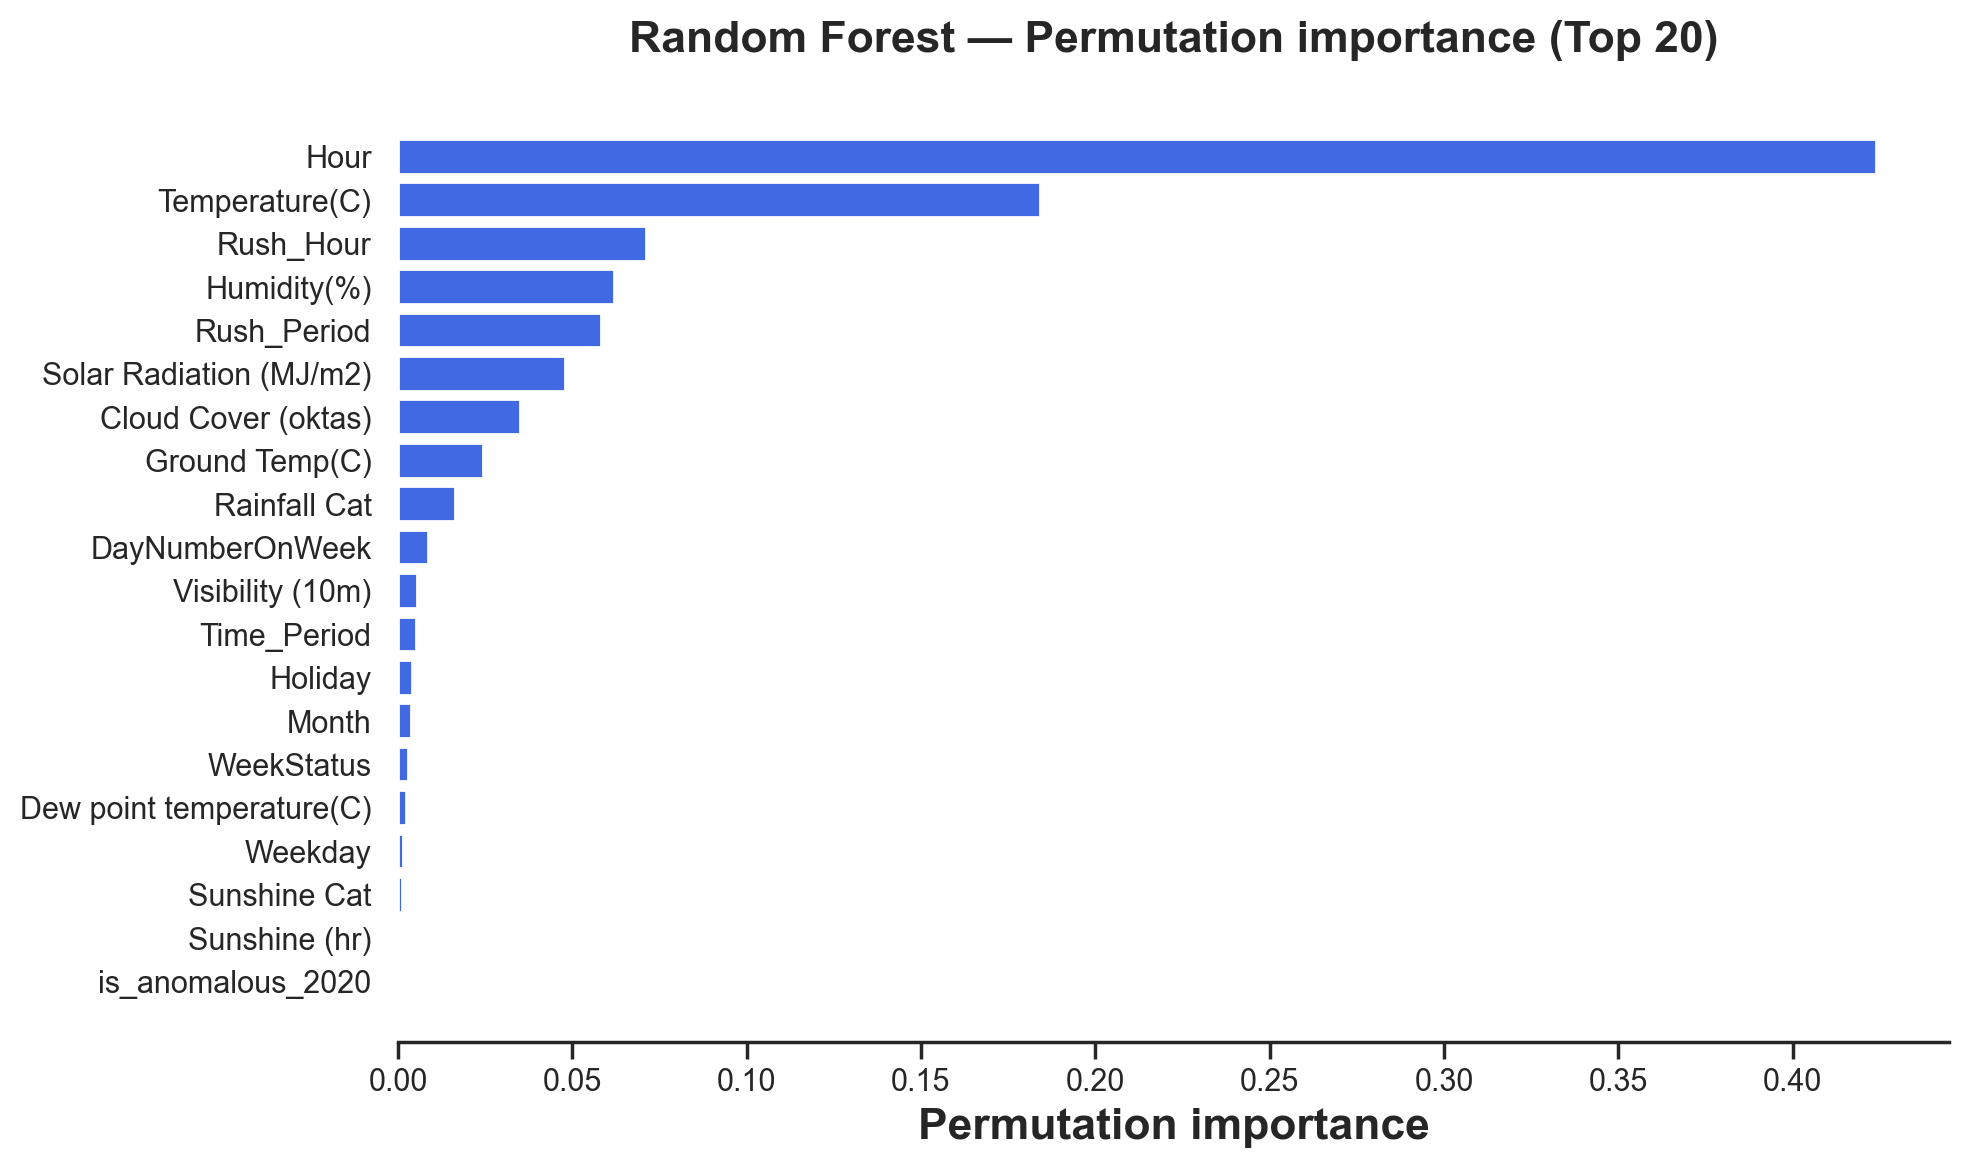

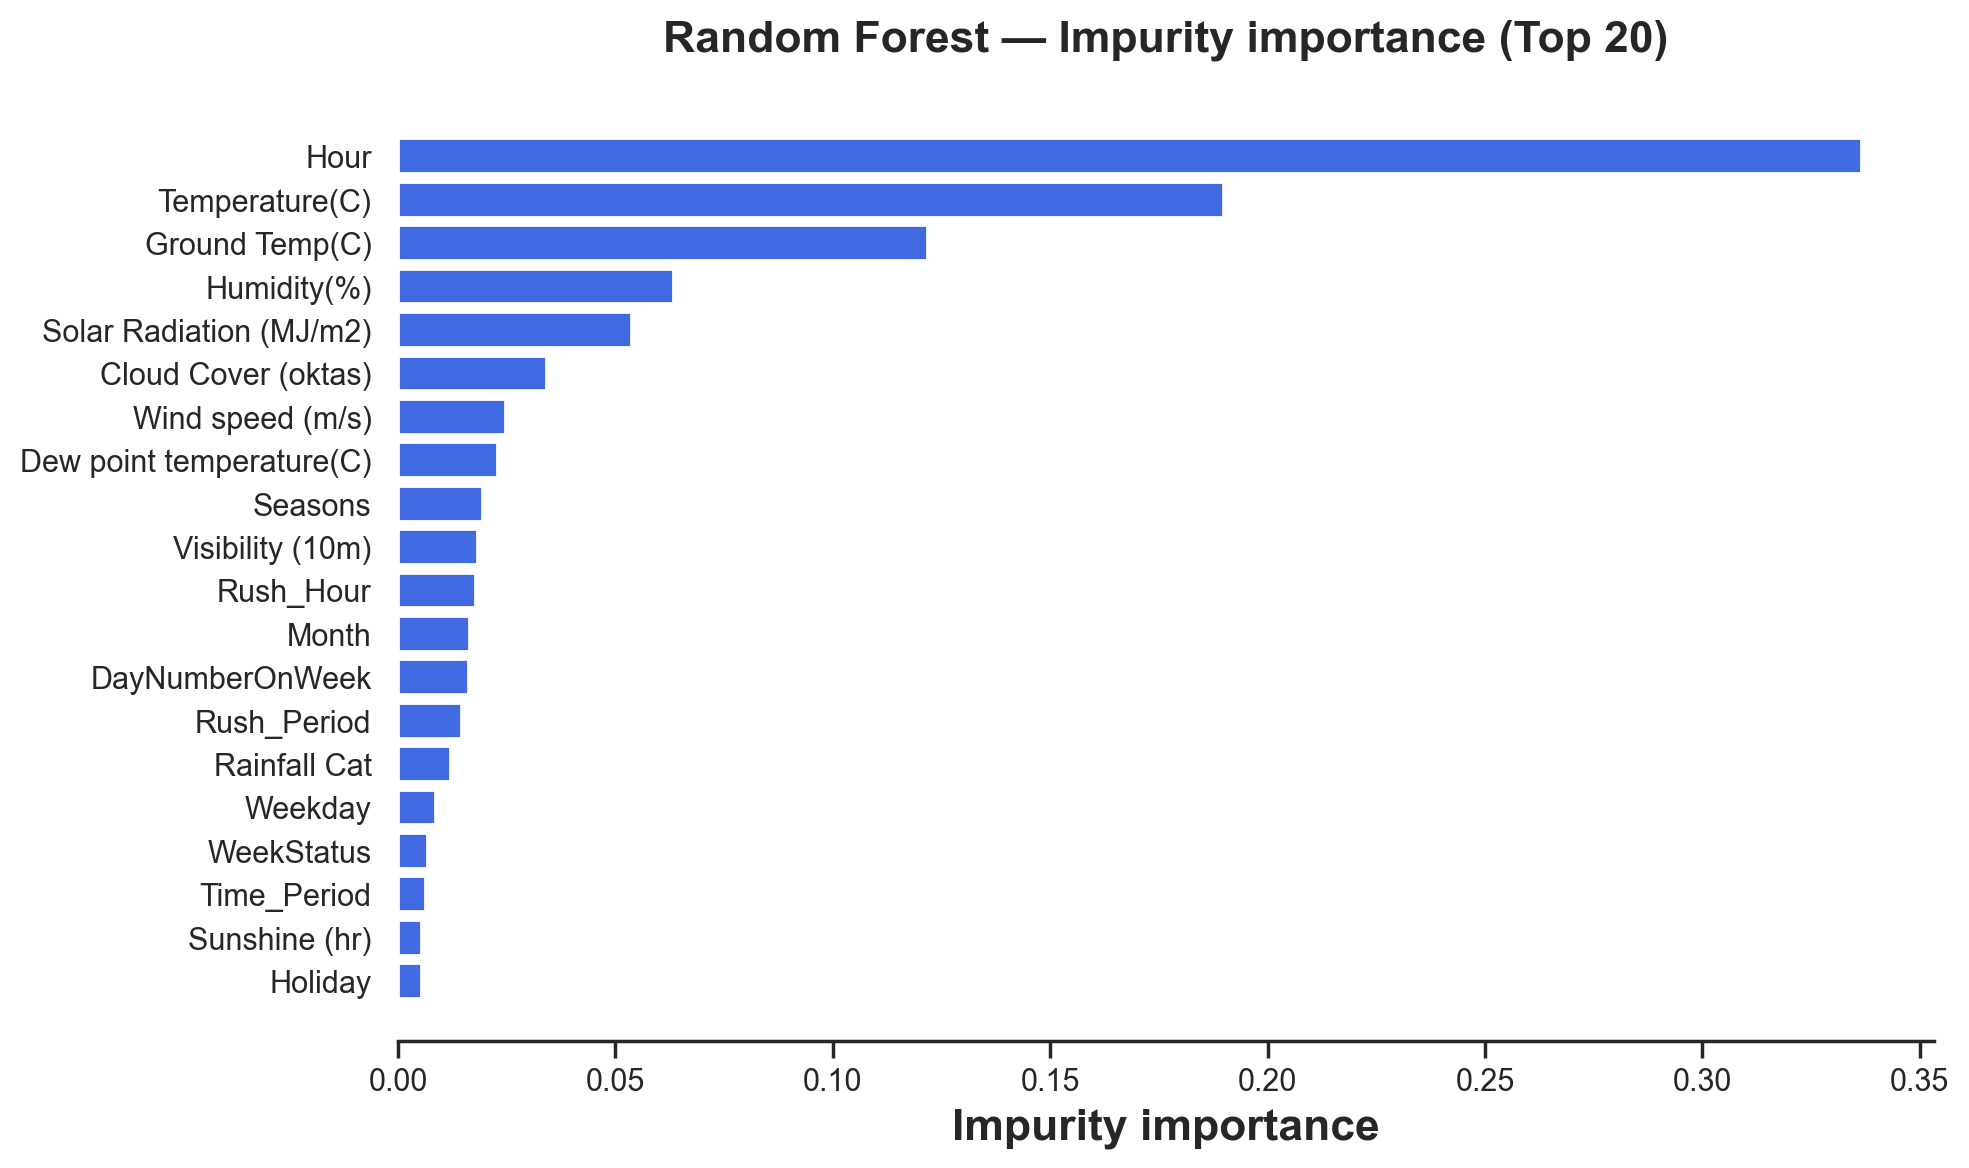

In [21]:
rf_sample, rf_sample_years, categorical_missing = fs.prepare_rf_sample(mv_df, meta['Year'])
msg = lang({
    'rf_on': 'Explicabilidade RF em',
    'retained': 'valores categóricos ausentes mantidos como categoria explícita de ausência',
    'rows': 'linhas',
})
print(f'{msg["rf_on"]} {len(rf_sample):,} {msg["rows"]}; '  # noqa: E501
      f'{categorical_missing:,} {msg["retained"]}')

mfa = fs.MultivariateFeatureAnalysis(
    target_col=TARGET, n_repeats=8, max_shap_samples=500,
).fit(rf_sample)

split_labels = lang({
    'target_mean': 'Média do alvo',
    'target_median': 'Mediana do alvo',
})
display(mfa.split_report(rf_sample_years, lang=lang).style.format({
    split_labels['target_mean']: '{:.3f}',
    split_labels['target_median']: '{:.3f}',
}))
display(mfa.baseline_metrics_.to_frame(
    lang({'bh': 'Linha de base (holdout)'})['bh']).T.style.format('{:.3f}'))
mfa.plot_feature_importance('permutation', lang=lang); plt.show()
mfa.plot_feature_importance('impurity', lang=lang); plt.show()


,Variable,Impurity importance,Permutation importance (mean),Permutation importance (standard deviation),mean |SHAP|
0,Hour,0.3365,0.4238,0.0078,0.3704
1,Temperature(C),0.1898,0.1840,0.0091,0.2688
2,Rush_Hour,0.0177,0.0712,0.0025,0.0626
3,Humidity(%),0.0631,0.0621,0.0044,0.0863
4,Rush_Period,0.0145,0.0583,0.0021,0.0521
5,Solar Radiation (MJ/m2),0.0536,0.0480,0.0027,0.0697
6,Cloud Cover (oktas),0.0340,0.0349,0.0028,0.0662
7,Ground Temp(C),0.1216,0.0243,0.0046,0.1345
8,Rainfall Cat,0.0120,0.0162,0.0015,0.0274
9,DayNumberOnWeek,0.0162,0.0087,0.0012,0.0157


,Removed variable,RMSE without the variable,MAE without the variable,R² without the variable,Δ RMSE,Δ MAE,Δ R²
0,Hour,0.4112,0.2733,0.7643,+0.0435,+0.0267,-0.0473
1,Visibility (10m),0.3761,0.2515,0.8028,+0.0084,+0.0048,-0.0087
2,Holiday,0.3746,0.2522,0.8044,+0.0069,+0.0055,-0.0071
3,Rainfall Cat,0.3738,0.2505,0.8052,+0.0062,+0.0039,-0.0064
4,Temperature(C),0.3707,0.2493,0.8084,+0.0030,+0.0026,-0.0031
5,Cloud Cover (oktas),0.3705,0.2490,0.8087,+0.0028,+0.0023,-0.0029
6,DayNumberOnWeek,0.3696,0.2480,0.8095,+0.0020,+0.0013,-0.0020
7,Dew point temperature(C),0.3688,0.2474,0.8103,+0.0012,+0.0008,-0.0012
8,is_anomalous_2020,0.3683,0.2471,0.8109,+0.0007,+0.0004,-0.0007
9,Snowfall Cat,0.3681,0.2468,0.8111,+0.0004,+0.0002,-0.0004


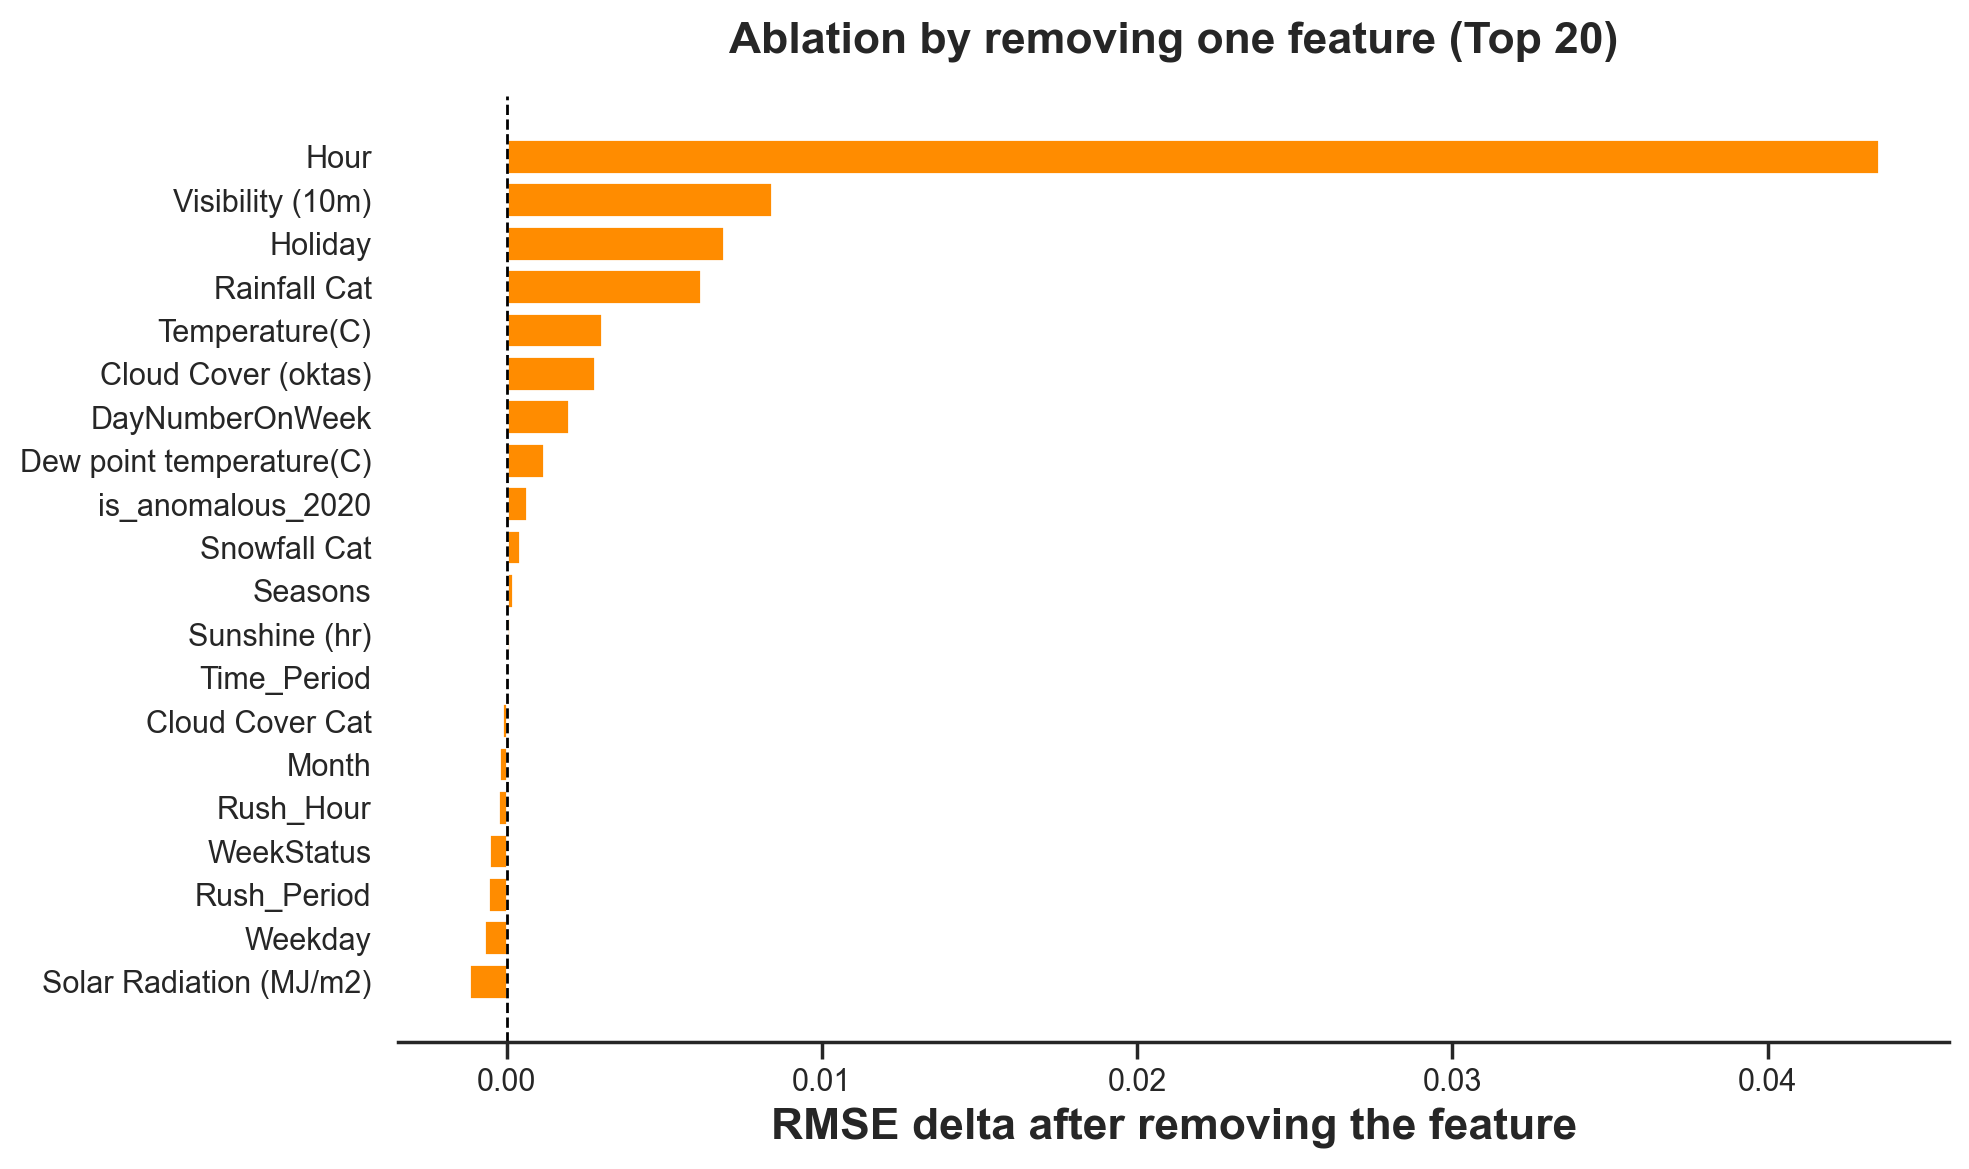

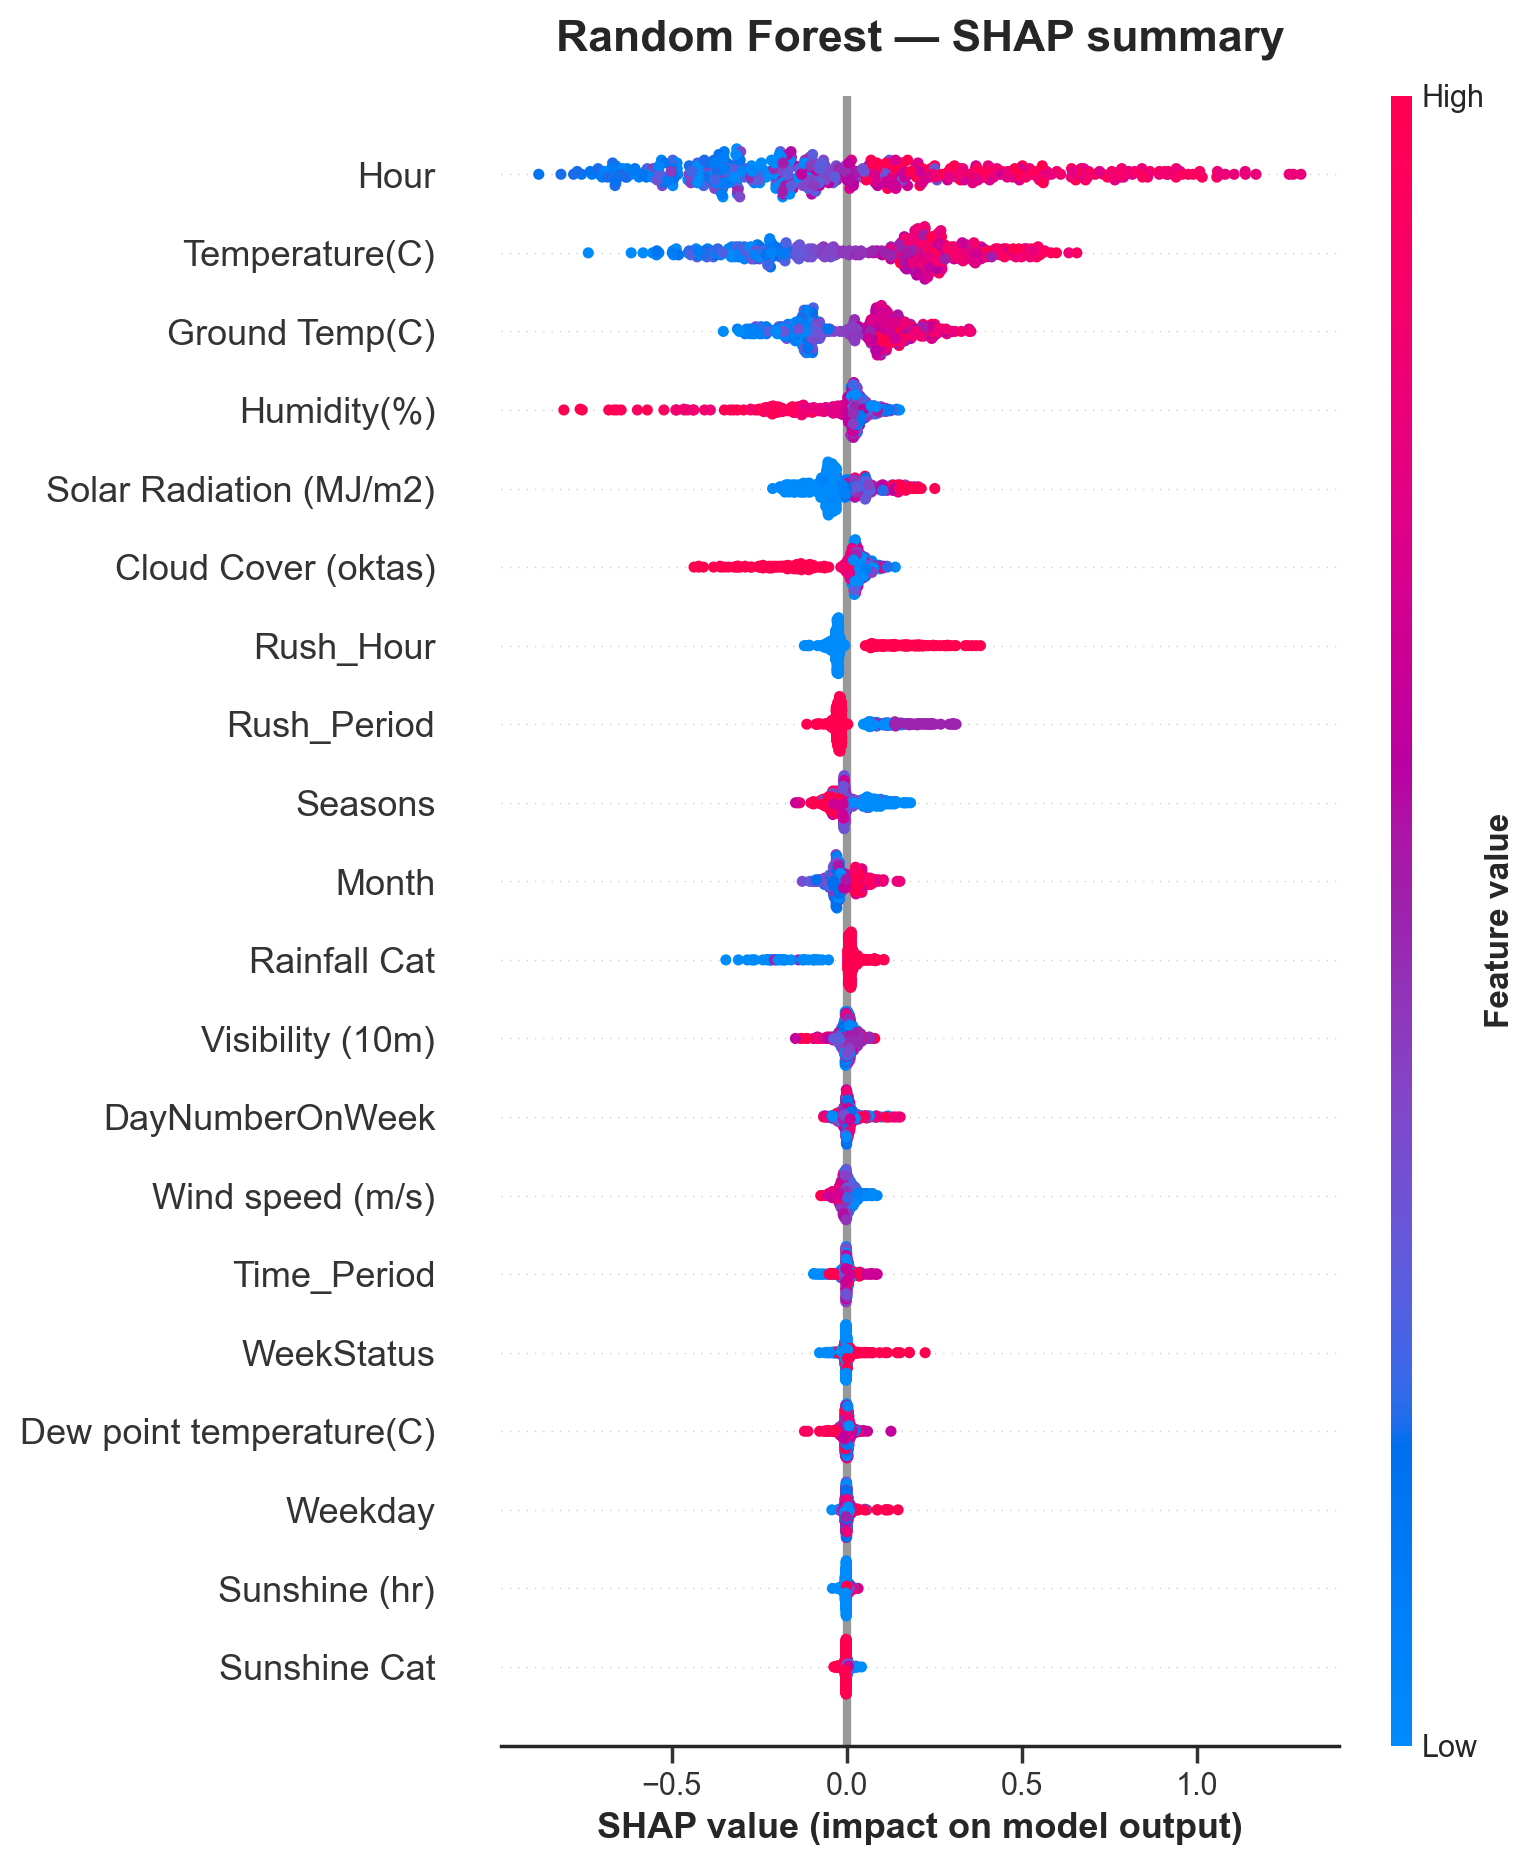

In [22]:
importance_labels = lang({
    'impurity': 'Importância por impureza',
    'permutation_mean': 'Importância por permutação (média)',
    'permutation_std': 'Importância por permutação (desvio-padrão)',
    'shap_mean': '|SHAP| médio',
})
importance_report = mfa.get_feature_importance_table(top_n=20)
display(fs.localize_importance_table(importance_report, lang=lang).style.format({
    importance_labels['impurity']: '{:.4f}',
    importance_labels['permutation_mean']: '{:.4f}',
    importance_labels['permutation_std']: '{:.4f}',
    importance_labels['shap_mean']: '{:.4f}',
}))

ablation_labels = lang({
    'rmse_without': 'RMSE sem a variável',
    'mae_without': 'MAE sem a variável',
    'r2_without': 'R² sem a variável',
    'delta_rmse': 'Δ RMSE',
    'delta_mae': 'Δ MAE',
    'delta_r2': 'Δ R²',
})
ablation_report = mfa.ablation_importance_df_.head(20)
display(fs.localize_ablation_table(ablation_report, lang=lang).style.format({
    ablation_labels['rmse_without']: '{:.4f}',
    ablation_labels['mae_without']: '{:.4f}',
    ablation_labels['r2_without']: '{:.4f}',
    ablation_labels['delta_rmse']: '{:+.4f}',
    ablation_labels['delta_mae']: '{:+.4f}',
    ablation_labels['delta_r2']: '{:+.4f}',
}))
mfa.plot_ablation(lang=lang); plt.show()
if mfa.shap_available_:
    mfa.plot_shap_summary(lang=lang); plt.show()
else:
    shap_msg = lang({'unavailable': 'SHAP não disponível:'})['unavailable']
    print(shap_msg, mfa.shap_note_)


>### Insight
>
> After preserving all 10,000 rows, the model trained on 2015–2021 and evaluated on 2022–2024 achieved `RMSE = 0.368`, `MAE = 0.247`, and `R² = 0.812`. Approximately 81% of the variance in the index within the balanced holdout was reconstructed by the Random Forest, but this result was obtained at a single temporal boundary and on a retrospective target. Future operational performance was not demonstrated.
>
> `Hour` was identified as the most robust driver. An impurity importance of `0.336`, a mean `RMSE` increase of `0.424` after permutation, and an increase of `0.045` after removal and refitting were obtained. The difference between permutation and ablation was expected: when `Hour` was removed, part of its information could be recovered through `Rush_Hour`, `Rush_Period`, and `Time_Period`; when only `Hour` was shuffled, combinations inconsistent with those derived variables were produced.
>
> Temperature also remained relevant by impurity (`0.190`) and permutation (`ΔRMSE = 0.185`), but its ablation increased `RMSE` by only `0.003`. Replacement through ground temperature, dew point, humidity, and seasonality was evidenced by this decline in incremental importance. Similarly, ground temperature received an impurity importance of `0.122`, but only `0.025` by permutation and a residual ablation close to zero. The rankings therefore confirmed an important thermal block, but not an independent contribution from every column.
>
> `Visibility (10m)` produced the second-largest ablation (`ΔRMSE = 0.008`), behind only `Hour`; `Holiday` (`ΔRMSE = 0.006`) and `Rainfall Cat` (`ΔRMSE = 0.006`) were virtually tied immediately afterward. `Rainfall Cat` produced only a `0.016` mean increase in `RMSE` under permutation, reinforcing the difference between the two importance perspectives. `Rush_Period`, `Rush_Hour`, and cloud cover also produced measurable deterioration when removed. In contrast, negative or near-zero importances for season, wind, humidity, and some derived features remained on the scale of fitting variation and were interpreted as redundancy or instability, not as proof of no association.
>
> Permuting `is_anomalous_2020` produced exactly zero because the flag is constant and equal to zero throughout the holdout. Because only 46 positive cases remained in training, the relevance of the anomalous regime could not be assessed through this window. The result neither authorizes removal of the flag nor supports an interpretation of the 2020 mechanism.
>
> Mean absolute SHAP values and the scatter plot must be read on the scale of the model contributions and should not be numerically compared with impurity proportions or `RMSE` deltas. For categories converted into integer codes, the direction and distance between colors also depend on an artificial ordering and are not assigned an ordinal interpretation.
>
> As a project decision, no feature will be manually excluded because of its position in a single ranking. Convergence across methods will be used as exploratory evidence, while redundancy, stability, and out-of-sample gain will be evaluated through `SelectKBest`, `RFE`, `SelectFromModel`, `SequentialFeatureSelector`, or `NoSelector`, always jointly with the estimator and with temporal validation by meteorological year.


## 9. Synthesis

The multivariate analysis was structured so that hourly, seasonal, and meteorological relationships could be examined without allowing the operation's long-term growth to dominate the results. Before testing, temporal integrity was addressed, the analytical target was redefined as relative demand, and conclusions were separated into association, redundancy, and out-of-sample predictive utility.

### Analytical Basis and Coverage

The May–December 2020 window was identified through a reproducible rule after observed demand fell to approximately 8%–50% of the geometric interpolation between 2019 and 2021. The cause could not be determined from the available data; a coverage artifact was considered plausible but was not assumed as fact. The rows were preserved and the period was flagged through `is_anomalous_2020`, while affected days were excluded only from baseline estimation.

The approximately 110-fold growth between 2015 and 2023 was treated as a change in the system's level and scale. A centered 365-day moving baseline was estimated from daily means, and the hourly count was converted into the multiplicative index `demand / baseline`. Linear correlation with time was reduced from `0.548` for raw demand to `0.0274` for the index. The target was defined for 75,304 of the 81,018 observations (`92.9%`); the 5,714 rows without an index were concentrated in the anomalous window, where the minimum of 180 valid days was not reached.

For complete and non-anomalous meteorological years, means close to 1 were obtained, ranging approximately from `0.943` to `1.008`. A broad seasonal shape was preserved, with lower relative demand during winter and higher demand during the warmer months and early autumn. Because amplitude differences remained across years, especially in September and October, recurrence of the general pattern was supported, but neither seasonal invariance nor an exclusively climatic explanation was established.

### Association and Redundancy Structure

In the year-balanced PhiK analysis, 33 pairs simultaneously presented `phik ≥ 0.50` and significance `Z ≥ 3`. The strongest associations were concentrated in representations derived from the same information, such as `DayNumberOnWeek`–`Weekday`, `Weekday`–`WeekStatus`, `Month`–`Seasons`, `Rush_Hour`–`Rush_Period`, `Hour`–`Time_Period`, and continuous variables paired with their discretized categories. Only `Rush_Period` reached `phik ≥ 0.50` with the target (`0.542`), but because it is a deterministic function of hour (`phik` of `1.000` with `Rush_Hour` and `0.825` with `Hour`), this association repeats the peak-hour signal. The next-highest values were observed for `Hour` (`0.481`), `Time_Period` (`0.458`), `Ground Temp(C)` (`0.385`), and `Temperature(C)` (`0.368`). A multivariate structure was indicated rather than a single predictor capable of strongly explaining relative demand.

Severe meteorological redundancy was confirmed by VIF with an intercept. VIF values of `149.86` for dew point, `132.71` for air temperature, `26.46` for humidity, and `21.53` for ground temperature were obtained; more than 99% of the variance in temperature and dew point could be linearly reconstructed from the other measurements examined. Solar radiation (`4.15`) and wind speed (`1.10`) remained below the ranges associated with high inflation. This diagnosis was interpreted as a risk to coefficient stability and individual attribution, not as evidence of predictive uselessness.

Relevant seasonal differences were supported by rank-based tests. The spring–winter and summer–winter contrasts produced rank-biserial correlations of `0.419` and `0.547`, and the global test across seasons yielded `ε² = 0.154`. Between summer and autumn, despite significance after Holm adjustment, an almost null effect was obtained (`r_rb = −0.021`). A moderate monotonic association was observed between temperature and relative demand (`ρ_s = 0.502`), whereas the difference between holidays and other days was small (`r_rb = −0.155`). It was therefore demonstrated that small p-values do not automatically imply practical relevance.

In the univariate filters, `Time_Period`, `Rush_Hour`, `Sunshine Cat`, and `Seasons` produced the largest Cramér's V values; ground temperature, air temperature, hour, and solar radiation produced the largest ANOVA separations; and temperature, ground temperature, hour, early morning, rush hour, and winter produced the largest isolated `R²` values in F-regression. Convergence around hour and the thermal block was reinforced, but independent contribution was not established because collinearity and derived representations were retained in these rankings. The `Q1`–`Q5` bands were used only for diagnosis and were not incorporated into the modeling frame.

Marginal normality was rejected for the index, temperature, and humidity. Positive skewness (`1.505`) and positive excess kurtosis (`2.766`) were observed in the target, whereas temperature and humidity were nearly symmetric and flatter than a Normal distribution. This rejection was not converted into automatic transformation or exclusion because parametric assumptions must be verified for the object to which they apply, such as residuals or conditional distributions. For precipitation, global differences after Holm adjustment were accompanied by `ε² = 0.076` for rain and `ε² = 0.034` for snow, with greater practical separation observed across the rain categories.

### Multivariate Evidence and Project Decision

In the Random Forest diagnosis, all 10,000 balanced observations were preserved after missing `Cloud Cover Cat` values were represented through a dedicated missing category. The model was trained on 2015–2021 and evaluated on 2022–2024, yielding `RMSE = 0.368`, `MAE = 0.247`, and `R² = 0.812`. `Hour` was the most robust feature across impurity, permutation, and ablation. The thermal block also remained important, but its contribution was redistributed across air temperature, ground temperature, dew point, humidity, and seasonality. `Visibility (10m)` produced the second-largest ablation behind only `Hour`, with `Holiday` and `Rainfall Cat` virtually tied immediately afterward; `Rainfall Cat` retained moderate permutation importance.

Divergence among the methods was preserved as information. Permutation, ablation, impurity, and SHAP measure different objects, and correlated or deterministic features alter the share attributed to each one. The null permutation importance of `is_anomalous_2020` was not interpreted as irrelevance: only 46 positive cases remained in training, and the flag was constant and equal to zero throughout the holdout. Likewise, encoding categories with integer labels was recognized as a limitation specific to this Random Forest explanation.

No feature was manually excluded based on the diagnostics in this notebook. All features will be retained as candidates, and selection will be treated as a joint part of the pipeline through `SelectKBest`, `RFE`, `SelectFromModel`, `SequentialFeatureSelector`, or `NoSelector`, according to compatibility with the estimator. Deterministic and meteorological redundancies should be interpreted through semantic groups when they remain in the model. The final decision must be supported by performance and stability under temporal validation by meteorological year, not by a universal ranking.

Finally, the evidence produced is associative and exploratory. Serial dependence, imbalance across groups, seasonal confounding, and the use of only one temporal boundary for the Random Forest limit inference. In addition, the centered moving average uses future observations in the retrospective construction of the index; the index must therefore not be used as a real-time feature or presented as an operational transformation ready for forecasting. If it is adopted as a modeling target, its baseline must be constructed causally within each partition or forecast separately, without access to the validation period.


### Methodological Reference

- Anderson, T. W., & Darling, D. A. (1952). *Asymptotic theory of certain ‘goodness of fit’ criteria based on stochastic processes*. **The Annals of Mathematical Statistics, 23**(2), 193–212. https://doi.org/10.1214/aoms/1177729437

- Baak, M., Koopman, R., Snoek, H., & Klous, S. (2020). *A new correlation coefficient between categorical, ordinal and interval variables with Pearson characteristics*. **Computational Statistics & Data Analysis, 152**, 107043. https://doi.org/10.1016/j.csda.2020.107043

- Breiman, L. (2001). *Random forests*. **Machine Learning, 45**, 5–32. https://doi.org/10.1023/A:1010933404324

- Fisher, R. A. (1925). *Statistical methods for research workers*. Edinburgh: Oliver and Boyd. https://openlibrary.org/works/OL1153861W/Statistical_methods_for_research_workers

- Holm, S. (1979). *A simple sequentially rejective multiple test procedure*. **Scandinavian Journal of Statistics, 6**(2), 65–70. https://www.jstor.org/stable/4615733

- Kerby, D. S. (2014). *The simple difference formula: An approach to teaching nonparametric correlation*. **Comprehensive Psychology, 3**, 11.IT.3.1. https://doi.org/10.2466/11.IT.3.1

- Kruskal, W. H., & Wallis, W. A. (1952). *Use of ranks in one-criterion variance analysis*. **Journal of the American Statistical Association, 47**(260), 583–621. https://doi.org/10.1080/01621459.1952.10483441

- Lundberg, S. M., & Lee, S.-I. (2017). *A unified approach to interpreting model predictions*. **Advances in Neural Information Processing Systems, 30**, 4765–4774. https://papers.neurips.cc/paper_files/paper/2017/hash/8a20a8621978632d76c43dfd28b67767-Abstract.html

- Mann, H. B., & Whitney, D. R. (1947). *On a test of whether one of two random variables is stochastically larger than the other*. **The Annals of Mathematical Statistics, 18**(1), 50–60. https://doi.org/10.1214/aoms/1177730491

- Miller, D. M., & Williams, D. (2003). *Shrinkage estimators of time series seasonal factors and their effect on forecasting accuracy*. **International Journal of Forecasting, 19**(4), 669–684. https://doi.org/10.1016/S0169-2070(02)00077-8

- O’Brien, R. M. (2007). *A caution regarding rules of thumb for variance inflation factors*. **Quality & Quantity, 41**(5), 673–690. https://doi.org/10.1007/s11135-006-9018-6

- Pearson, K. (1900). *On the criterion that a given system of deviations from the probable in the case of a correlated system of variables is such that it can be reasonably supposed to have arisen from random sampling*. **The London, Edinburgh, and Dublin Philosophical Magazine and Journal of Science, 50**(302), 157–175. https://doi.org/10.1080/14786440009463897

- Shapiro, S. S., & Wilk, M. B. (1965). *An analysis of variance test for normality (complete samples)*. **Biometrika, 52**(3–4), 591–611. https://doi.org/10.1093/biomet/52.3-4.591

- Spearman, C. (1904). *The proof and measurement of association between two things*. **The American Journal of Psychology, 15**(1), 72–101. https://doi.org/10.2307/1412159

- Strobl, C., Boulesteix, A.-L., Zeileis, A., & Hothorn, T. (2007). *Bias in random forest variable importance measures: Illustrations, sources and a solution*. **BMC Bioinformatics, 8**, 25. https://doi.org/10.1186/1471-2105-8-25
